# Biodiversity + Climate Integration — Clean, Ordered, and Application-Oriented

This notebook is a **full reorganization** of the climate-integration workflow around four separate goals:

1. **Build one clean global country-year environmental panel**.
2. **Run fair forecasting experiments** where the lag-based biodiversity baseline is compared against the same rows augmented with environmental features.
3. **Measure global environmental signal** with permutation importance and category ablation.
4. **Provide an application-ready population function** that takes a `population_id` and a forecast horizon and returns:
   - the historical + forecast trajectory,
   - uncertainty bands,
   - the top climatic / anthropogenic drivers,
   - optional IUCN lookup information.

The notebook keeps forecasting and interpretation separate on purpose:
- **forecasting** is about predictive performance;
- **driver analysis** is about which environmental variables matter most for one monitored population.

---

## 0. What is intentionally in scope

### Core environmental block
- temperature
- precipitation
- forest cover
- annual forest change
- agricultural land
- wildfire intensity

### Feature-engineering philosophy
For each environmental family, the notebook keeps:
- the **base country-year feature**,
- a small set of **transformed versions** likely to be more predictive:
  - lag,
  - change,
  - rolling mean,
  - anomaly relative to the country mean.

### Important forecasting note
A 10–20 year forecast is possible **only under a future environmental scenario assumption**.
This notebook therefore supports:
- `future_env_strategy="hold_last"` → hold the last observed environmental values constant;
- `future_env_df=...` → pass your own future country-year scenario table.

So the long-horizon forecast is operationally useful, but it is **scenario-dependent**, not an authoritative ecological truth.

In [1]:
from pathlib import Path
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    XGBRegressor = None
    HAS_XGBOOST = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

print("xgboost available:", HAS_XGBOOST)

xgboost available: True


In [2]:
# =========================================================
# 1. PATHS, CONFIG, AND USER INPUTS
# =========================================================
PROJECT_ROOT = Path("..").resolve()

DEFAULT_BIODIVERSITY_PATH = (
    PROJECT_ROOT / "data" / "interim" / "strict_forecasting" /
    "lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv"
)

CLIMATE_CANDIDATE_DIRS = [
    PROJECT_ROOT / "data" / "external" / "climate",
    Path.cwd(),
    Path("/mnt/data"),
]

# Optional IUCN lookup file.
# Expected current-status columns:
# - binomial
# - iucn_category
# - assessment_year (optional)
#
# Optional scenario-status columns:
# - binomial
# - target_year
# - projected_iucn_category
IUCN_CURRENT_LOOKUP_PATH = None
IUCN_SCENARIO_LOOKUP_PATH = None

# Core modeling settings
N_LAGS = 4
TEST_YEARS = 5
LOCAL_TEST_YEARS = 4
RANDOM_STATE = 42
LOCAL_MIN_SERIES_ROWS = 12
MAX_FUTURE_HORIZON = 20
N_BOOTSTRAP_PATHS = 300

# Optional extension: switch on later if you want "human pressure"
USE_URBAN_PRESSURE = False

def resolve_input_file(filename, candidate_dirs=None):
    candidate_dirs = candidate_dirs or CLIMATE_CANDIDATE_DIRS
    checked = []
    for d in candidate_dirs:
        p = d / filename
        checked.append(str(p))
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {filename!r}. Checked: {checked}")

print("Project root:", PROJECT_ROOT)
print("Default biodiversity path:", DEFAULT_BIODIVERSITY_PATH)
for d in CLIMATE_CANDIDATE_DIRS:
    print("Climate search dir:", d)

Project root: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction
Default biodiversity path: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\strict_forecasting\lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv
Climate search dir: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\external\climate
Climate search dir: c:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\notebooks
Climate search dir: \mnt\data


In [3]:
# =========================================================
# 2. ENVIRONMENTAL SOURCE CONFIGURATION
# =========================================================
ENV_SOURCES = {
    "temperature": {
        "filename": "average-annual-surface-temperature.csv",
        "value_col": "Average surface temperature",
        "raw_col": "temp_avg_c",
        "model_col": "temp_avg_c",
        "category": "temperature",
        "enabled": True,
        "year_min": None,
        "year_max": None,
        "transform": None,
        "interpolate_inside": True,
    },
    "precipitation": {
        "filename": "average-precipitation-per-year.csv",
        "value_col": "Annual precipitation",
        "raw_col": "precip_mm",
        "model_col": "precip_mm",
        "category": "water",
        "enabled": True,
        "year_min": None,
        "year_max": None,
        "transform": None,
        "interpolate_inside": True,
    },
    "forest_share": {
        "filename": "forest-area-as-share-of-land-area.csv",
        "value_col": "Share of land covered by forest",
        "raw_col": "forest_share_pct",
        "model_col": "forest_share_pct",
        "category": "habitat_cover",
        "enabled": True,
        "year_min": 1990,
        "year_max": None,
        "transform": None,
        "interpolate_inside": True,
    },
    "forest_change": {
        "filename": "annual-change-forest-area.csv",
        "value_col": "Annual change in forest area",
        "raw_col": "forest_change_ha",
        "model_col": "forest_change_ha",
        "category": "habitat_change",
        "enabled": True,
        "year_min": 1991,
        "year_max": None,
        "transform": None,
        "interpolate_inside": True,
    },
    "agricultural_land": {
        "filename": "agricultural-land.csv",
        "value_col": "Agricultural land - Area (hectares)",
        "raw_col": "agricultural_land_ha",
        "model_col": "agricultural_land_log1p",
        "category": "land_use",
        "enabled": True,
        "year_min": None,
        "year_max": None,
        "transform": "log1p_nonnegative",
        "interpolate_inside": True,
    },
    "wildfire": {
        "filename": "annual-area-burnt-per-wildfire.csv",
        "value_col": "Annual area burnt per wildfire",
        "raw_col": "wildfire_area_ha_per_fire",
        "model_col": "wildfire_area_ha_per_fire_log1p",
        "category": "disturbance",
        "enabled": True,
        "year_min": None,
        "year_max": 2025,
        "transform": "log1p_nonnegative",
        "interpolate_inside": False,
    },
    "urban_pressure": {
        "filename": "urban-population-share-2050.csv",
        "value_col": "Share of population residing in urban areas",
        "raw_col": "urban_share_pct",
        "model_col": "urban_share_pct",
        "category": "human_pressure",
        "enabled": USE_URBAN_PRESSURE,
        "year_min": 1950,
        "year_max": 2050,
        "transform": None,
        "interpolate_inside": True,
    },
}

ACTIVE_ENV_SOURCES = {
    name: cfg for name, cfg in ENV_SOURCES.items()
    if cfg.get("enabled", False)
}

BASE_ENV_MODEL_FEATURES = list(dict.fromkeys([
    cfg["model_col"] for cfg in ACTIVE_ENV_SOURCES.values()
]))
BASE_ENV_RAW_FEATURES = list(dict.fromkeys([
    cfg["raw_col"] for cfg in ACTIVE_ENV_SOURCES.values()
]))

print("Active sources:", list(ACTIVE_ENV_SOURCES.keys()))
print("Base model env features:", BASE_ENV_MODEL_FEATURES)

Active sources: ['temperature', 'precipitation', 'forest_share', 'forest_change', 'agricultural_land', 'wildfire']
Base model env features: ['temp_avg_c', 'precip_mm', 'forest_share_pct', 'forest_change_ha', 'agricultural_land_log1p', 'wildfire_area_ha_per_fire_log1p']


In [4]:
# =========================================================
# 3. GENERIC HELPERS
# =========================================================
def normalize_country_name(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)

    country_fixes = {
        "usa": "united states",
        "us": "united states",
        "u.s.a.": "united states",
        "u.s.": "united states",
        "uk": "united kingdom",
        "czech republic": "czechia",
        "viet nam": "vietnam",
        "russian federation": "russia",
        "republic of korea": "south korea",
        "korea, republic of": "south korea",
        "korea, dem. people's rep.": "north korea",
        "democratic republic of the congo": "democratic republic of congo",
        "dr congo": "democratic republic of congo",
        "republic of the congo": "congo",
        "congo, rep.": "congo",
        "congo, dem. rep.": "democratic republic of congo",
        "swaziland": "eswatini",
        "syrian arab republic": "syria",
        "iran, islamic republic of": "iran",
        "lao pdr": "laos",
        "bolivia (plurinational state of)": "bolivia",
        "venezuela (bolivarian republic of)": "venezuela",
        "türkiye": "turkey",
        "myanmar (burma)": "myanmar",
        "cape verde": "cabo verde",
        "slovak republic": "slovakia",
        "occupied palestinian territory": "palestine",
        "state of palestine": "palestine",
        "moldova, republic of": "moldova",
        "brunei darussalam": "brunei",
    }
    return country_fixes.get(x, x)


def keep_country_rows(df, code_col="Code"):
    if code_col not in df.columns:
        return df.copy()

    out = df.copy()
    out[code_col] = out[code_col].astype(str)
    return out[out[code_col].str.fullmatch(r"[A-Z]{3}", na=False)].copy()


def build_series_id(df):
    parts = []

    if "id" in df.columns:
        return df["id"].astype(str)

    if "common_name" in df.columns:
        parts.append(df["common_name"].astype(str))
    elif "binomial" in df.columns:
        parts.append(df["binomial"].astype(str))

    if "country" in df.columns:
        parts.append(df["country"].astype(str))

    if "location" in df.columns:
        parts.append(df["location"].astype(str))

    if not parts:
        return pd.Series(np.arange(len(df)).astype(str), index=df.index)

    series_id = parts[0]
    for p in parts[1:]:
        series_id = series_id + "|" + p
    return series_id


def wide_to_long(df, year_columns):
    id_columns = [c for c in df.columns if c not in year_columns]

    out = (
        df.melt(
            id_vars=id_columns,
            value_vars=year_columns,
            var_name="Year",
            value_name="Population",
        )
        .dropna(subset=["Population"])
        .copy()
    )

    out["Year"] = out["Year"].astype(int)
    out["series_id"] = build_series_id(out)
    out["Population"] = pd.to_numeric(out["Population"], errors="coerce")
    out = out.dropna(subset=["Population"]).copy()
    out["log_population"] = np.log1p(out["Population"])
    return out


def temporal_split(df, test_years=5):
    years = sorted(df["Year"].dropna().unique())
    if len(years) <= test_years:
        raise ValueError("Not enough unique years for the requested temporal split.")
    test_year_values = years[-test_years:]
    train_df = df[df["Year"] < min(test_year_values)].copy().reset_index(drop=True)
    test_df = df[df["Year"].isin(test_year_values)].copy().reset_index(drop=True)
    return train_df, test_df, test_year_values


def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nmae = mae / max(np.mean(np.abs(y_true)), 1e-9)
    wape = np.sum(np.abs(y_true - y_pred)) / max(np.sum(np.abs(y_true)), 1e-9)

    smape_denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = smape_denom != 0
    smape = (
        np.mean(np.abs(y_true[valid] - y_pred[valid]) / smape_denom[valid])
        if np.any(valid) else np.nan
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "NMAE": nmae,
        "WAPE": wape,
        "sMAPE": smape,
    }


def feature_coverage_summary(df, feature_cols, group_col="country_norm"):
    if not df.columns.is_unique:
        dupes = pd.Index(df.columns)[pd.Index(df.columns).duplicated()].unique().tolist()
        raise ValueError(f"Duplicate column names detected: {dupes}")

    rows = []
    for col in feature_cols:
        if col not in df.columns:
            rows.append({
                "feature": col,
                "non_null_rows": np.nan,
                "share_non_null": np.nan,
                "groups_with_data": np.nan,
                "year_min_with_data": np.nan,
                "year_max_with_data": np.nan,
                "note": "feature missing",
            })
            continue

        series = df[col]
        mask = series.notna()
        rows.append({
            "feature": col,
            "non_null_rows": int(mask.sum()),
            "share_non_null": float(mask.mean()),
            "groups_with_data": int(df.loc[mask, group_col].nunique()) if group_col in df.columns else np.nan,
            "year_min_with_data": int(df.loc[mask, "Year"].min()) if mask.any() else np.nan,
            "year_max_with_data": int(df.loc[mask, "Year"].max()) if mask.any() else np.nan,
            "note": "",
        })
    return pd.DataFrame(rows).sort_values(
        ["share_non_null", "feature"],
        ascending=[False, True],
        na_position="last",
    )


def safe_log1p_nonnegative(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce")
    return np.log1p(x.clip(lower=0))

In [5]:
# =========================================================
# 4. ENVIRONMENTAL DATA CLEANING + FEATURE ENGINEERING
# =========================================================
def clean_owid_country_year_feature(
    csv_path,
    value_col,
    raw_col,
    model_col,
    year_min=None,
    year_max=None,
    transform=None,
):
    df = pd.read_csv(csv_path)

    keep_cols = ["Entity", "Code", "Year", value_col]
    missing_cols = [c for c in keep_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in {csv_path.name}: {missing_cols}")

    df = df[keep_cols].copy()
    df = keep_country_rows(df, code_col="Code")

    df = df.rename(
        columns={
            "Entity": "country_source",
            "Code": "country_code",
            "Year": "Year",
            value_col: raw_col,
        }
    )

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)

    if year_min is not None:
        df = df[df["Year"] >= year_min].copy()
    if year_max is not None:
        df = df[df["Year"] <= year_max].copy()

    df[raw_col] = pd.to_numeric(df[raw_col], errors="coerce")
    df["country_norm"] = df["country_source"].apply(normalize_country_name)

    if transform is None:
        df[model_col] = df[raw_col]
    elif transform == "log1p_nonnegative":
        df[model_col] = np.log1p(df[raw_col].clip(lower=0))
    else:
        raise ValueError(f"Unsupported transform: {transform}")

    df = (
        df.sort_values(["country_norm", "Year"])
        .drop_duplicates(subset=["country_norm", "Year"], keep="last")
        .reset_index(drop=True)
    )
    return df


def interpolate_inside_country(df, feature_cols):
    out = df.sort_values(["country_norm", "Year"]).copy()
    for col in feature_cols:
        if col not in out.columns:
            continue
        out[col] = (
            out.groupby("country_norm")[col]
            .transform(lambda s: s.interpolate(limit_area="inside"))
        )
    return out


def add_country_env_transforms(env_panel, base_model_features):
    out = env_panel.sort_values(["country_norm", "Year"]).copy()

    for col in base_model_features:
        if col not in out.columns:
            continue

        grouped = out.groupby("country_norm")[col]
        out[f"{col}_lag1_country"] = grouped.shift(1)
        out[f"{col}_change"] = grouped.diff()
        out[f"{col}_roll3"] = grouped.transform(lambda s: s.rolling(3, min_periods=2).mean())
        out[f"{col}_anomaly_country"] = out[col] - grouped.transform("mean")

    if "wildfire_area_ha_per_fire" in out.columns:
        out["wildfire_occurrence"] = (out["wildfire_area_ha_per_fire"].fillna(0) > 0).astype(float)
        out["wildfire_occurrence_roll3"] = (
            out.groupby("country_norm")["wildfire_occurrence"]
            .transform(lambda s: s.rolling(3, min_periods=1).mean())
        )
        out["wildfire_shock"] = (
            out["wildfire_area_ha_per_fire"] -
            out.groupby("country_norm")["wildfire_area_ha_per_fire"]
            .transform(lambda s: s.rolling(3, min_periods=2).mean())
        )

    if "forest_change_ha" in out.columns:
        out["forest_change_sign"] = np.sign(out["forest_change_ha"])

    return out


def apply_base_env_transform(raw_value, transform):
    if pd.isna(raw_value):
        return np.nan
    if transform is None:
        return raw_value
    if transform == "log1p_nonnegative":
        return float(np.log1p(max(raw_value, 0)))
    raise ValueError(f"Unsupported transform: {transform}")


def recompute_country_env_history(country_history, base_model_features):
    country_history = country_history.sort_values("Year").copy()
    country_history = add_country_env_transforms(country_history, base_model_features)
    return country_history

In [6]:
# =========================================================
# 5. MODELING HELPERS
# =========================================================
def make_preprocessor(numeric_features, categorical_features):
    transformers = []

    if numeric_features:
        transformers.append(
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_features,
            )
        )

    if categorical_features:
        transformers.append(
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_onehot_encoder()),
                ]),
                categorical_features,
            )
        )

    return ColumnTransformer(transformers=transformers, remainder="drop")


def get_model_grid(preprocessor):
    models = {
        "RandomForest": (
            Pipeline([
                ("prep", preprocessor),
                ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
            ]),
            {
                "model__n_estimators": [250],
                "model__max_depth": [8, None],
                "model__min_samples_leaf": [1, 3],
            },
        ),
        "HistGBR": (
            Pipeline([
                ("prep", preprocessor),
                ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
            ]),
            {
                "model__max_depth": [None, 8],
                "model__learning_rate": [0.05, 0.1],
                "model__max_iter": [200],
            },
        ),
    }

    if HAS_XGBOOST:
        models["XGBoost"] = (
            Pipeline([
                ("prep", preprocessor),
                ("model", XGBRegressor(
                    random_state=RANDOM_STATE,
                    objective="reg:squarederror",
                    tree_method="hist",
                    n_estimators=250,
                    n_jobs=-1,
                    eval_metric="mae",
                )),
            ]),
            {
                "model__max_depth": [4, 6],
                "model__learning_rate": [0.05, 0.1],
                "model__subsample": [0.8, 1.0],
                "model__colsample_bytree": [0.8, 1.0],
            },
        )

    return models


def build_internal_temporal_cv(df, val_years=2):
    years = sorted(df["Year"].unique())
    val_years = min(val_years, max(1, len(years) - 1))
    chosen_val_years = years[-val_years:]
    train_idx = np.where(df["Year"] < min(chosen_val_years))[0]
    val_idx = np.where(df["Year"].isin(chosen_val_years))[0]
    if len(train_idx) == 0 or len(val_idx) == 0:
        split = int(max(1, int(len(df) * 0.8)))
        train_idx = np.arange(split)
        val_idx = np.arange(split, len(df))
    return [(train_idx, val_idx)]


def add_lag_features(long_df, n_lags=4):
    out = long_df.sort_values(["series_id", "Year"]).copy()
    grouped_pop = out.groupby("series_id")["Population"]

    for lag in range(1, n_lags + 1):
        out[f"lag_{lag}"] = grouped_pop.shift(lag)

    out["prev_year"] = out.groupby("series_id")["Year"].shift(1)
    out["year_gap_from_prev"] = out["Year"] - out["prev_year"]

    out["rolling_mean_3"] = (
        grouped_pop.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    )
    out["rolling_std_3"] = (
        grouped_pop.shift(1).rolling(3).std().reset_index(level=0, drop=True)
    )

    out["population_difference"] = out["lag_1"] - out["lag_2"]
    out["population_growth_rate"] = (
        (out["lag_1"] - out["lag_2"]) / out["lag_2"].replace(0, np.nan)
    ).replace([np.inf, -np.inf], np.nan)

    required_lags = [f"lag_{i}" for i in range(1, n_lags + 1)]
    out = out.dropna(subset=required_lags).copy()
    return out


def build_feature_columns(
    df,
    include_lags=True,
    env_features=None,
    include_static_metadata=True,
    static_numeric_features=None,
    static_categorical_features=None,
    n_lags=4,
):
    env_features = env_features or []
    static_numeric_features = static_numeric_features or []
    static_categorical_features = static_categorical_features or []

    numeric = ["Year"]

    if include_static_metadata:
        numeric += [c for c in static_numeric_features if c in df.columns]

    if include_lags:
        lag_numeric = [
            *[f"lag_{i}" for i in range(1, n_lags + 1)],
            "year_gap_from_prev",
            "rolling_mean_3",
            "rolling_std_3",
            "population_difference",
            "population_growth_rate",
        ]
        numeric += [c for c in lag_numeric if c in df.columns]

    numeric += [c for c in env_features if c in df.columns]
    numeric = list(dict.fromkeys(numeric))

    categorical = []
    if include_static_metadata:
        categorical += [c for c in static_categorical_features if c in df.columns]
    categorical = list(dict.fromkeys(categorical))

    return {
        "numeric_features": numeric,
        "categorical_features": categorical,
        "feature_columns": numeric + categorical,
    }


def run_model_comparison(df, feature_columns, categorical_features, label):
    needed = feature_columns + ["log_population", "Population", "Year"]
    clean_df = df.dropna(subset=["log_population", "Population", "Year"]).copy()
    train_df, test_df, test_year_values = temporal_split(clean_df, test_years=TEST_YEARS)

    X_train = train_df[feature_columns].copy()
    y_train = train_df["log_population"].copy()
    X_test = test_df[feature_columns].copy()
    y_test = test_df["Population"].copy()
    y_test_log = test_df["log_population"].copy()

    numeric_features = [c for c in feature_columns if c not in categorical_features]
    preprocessor = make_preprocessor(numeric_features, categorical_features)
    model_grid = get_model_grid(preprocessor)

    rows = []
    importance_tables = {}
    fitted_models = {}

    cv = build_internal_temporal_cv(train_df, val_years=min(2, TEST_YEARS))

    for model_name, (pipeline, param_grid) in model_grid.items():
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        grid.fit(X_train, y_train)

        best_estimator = grid.best_estimator_
        pred_log = best_estimator.predict(X_test)
        pred_population = np.clip(np.expm1(pred_log), a_min=0, a_max=None)
        metrics = evaluate_regression(y_test.to_numpy(), pred_population)

        rows.append({
            "feature_set": label,
            "model": model_name,
            **metrics,
            "n_train": len(train_df),
            "n_test": len(test_df),
            "test_year_start": min(test_year_values),
            "test_year_end": max(test_year_values),
            "best_params": str(grid.best_params_),
        })

        perm = permutation_importance(
            best_estimator,
            X_test,
            y_test_log,
            n_repeats=8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

        importance_df = pd.DataFrame({
            "feature": feature_columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
            "feature_set": label,
            "model": model_name,
        }).sort_values("importance_mean", ascending=False)

        importance_tables[model_name] = importance_df
        fitted_models[model_name] = {
            "estimator": best_estimator,
            "best_params": grid.best_params_,
            "train_df": train_df,
            "test_df": test_df,
            "feature_columns": feature_columns,
            "categorical_features": categorical_features,
            "pred_log": pred_log,
            "pred_population": pred_population,
            "y_test": y_test.to_numpy(),
            "y_test_log": y_test_log.to_numpy(),
            "residuals_log": y_test_log.to_numpy() - pred_log,
        }

    return pd.DataFrame(rows), importance_tables, fitted_models


def refit_model_on_full_frame(df, feature_columns, categorical_features, model_name, best_params):
    numeric_features = [c for c in feature_columns if c not in categorical_features]
    preprocessor = make_preprocessor(numeric_features, categorical_features)
    model_grid = get_model_grid(preprocessor)
    pipeline, _ = model_grid[model_name]

    model = clone(pipeline)
    model.set_params(**best_params)
    model.fit(df[feature_columns], df["log_population"])
    return model

## 6. Load and clean all environmental sources

This section:
- loads each environmental source independently,
- standardizes country names,
- builds a single `country_norm + Year` panel,
- adds transformed environmental features for stronger signal extraction.

In [7]:
# =========================================================
# 6A. LOAD ALL ENVIRONMENTAL TABLES
# =========================================================
env_tables = {}
env_source_rows = []

for source_name, cfg in ACTIVE_ENV_SOURCES.items():
    file_path = resolve_input_file(cfg["filename"])

    cleaned = clean_owid_country_year_feature(
        csv_path=file_path,
        value_col=cfg["value_col"],
        raw_col=cfg["raw_col"],
        model_col=cfg["model_col"],
        year_min=cfg["year_min"],
        year_max=cfg["year_max"],
        transform=cfg["transform"],
    )

    env_tables[source_name] = cleaned

    env_source_rows.append({
        "source": source_name,
        "category": cfg["category"],
        "filename": cfg["filename"],
        "rows": len(cleaned),
        "countries": cleaned["country_norm"].nunique(),
        "year_min": cleaned["Year"].min(),
        "year_max": cleaned["Year"].max(),
        "raw_col": cfg["raw_col"],
        "model_col": cfg["model_col"],
    })

env_source_summary = pd.DataFrame(env_source_rows).sort_values(["category", "source"])
display(env_source_summary)

,source,category,filename,rows,countries,year_min,year_max,raw_col,model_col
5,wildfire,disturbance,annual-area-burnt-per-wildfire.csv,2475,201,2012,2025,wildfire_area_ha_per_fire,wildfire_area_ha_per_fire_log1p
3,forest_change,habitat_change,annual-change-forest-area.csv,8225,235,1991,2025,forest_change_ha,forest_change_ha
2,forest_share,habitat_cover,forest-area-as-share-of-land-area.csv,7637,213,1990,2025,forest_share_pct,forest_share_pct
4,agricultural_land,land_use,agricultural-land.csv,13118,226,1961,2023,agricultural_land_ha,agricultural_land_log1p
0,temperature,temperature,average-annual-surface-temperature.csv,16598,193,1940,2025,temp_avg_c,temp_avg_c
1,precipitation,water,average-precipitation-per-year.csv,16512,192,1940,2025,precip_mm,precip_mm


In [8]:
# =========================================================
# 6B. BUILD ONE GLOBAL COUNTRY-YEAR ENVIRONMENTAL PANEL
# =========================================================
env_panel = None

for source_name, cfg in ACTIVE_ENV_SOURCES.items():
    cols_to_keep = ["country_norm", "Year"]
    if cfg["raw_col"] == cfg["model_col"]:
        cols_to_keep.append(cfg["model_col"])
    else:
        cols_to_keep.extend([cfg["raw_col"], cfg["model_col"]])

    cols_to_keep = list(dict.fromkeys(cols_to_keep))
    source_df = env_tables[source_name][cols_to_keep].copy()

    if env_panel is None:
        env_panel = source_df
    else:
        env_panel = env_panel.merge(
            source_df,
            on=["country_norm", "Year"],
            how="outer",
            validate="one_to_one",
        )

env_panel = env_panel.sort_values(["country_norm", "Year"]).reset_index(drop=True)

duplicate_cols = pd.Index(env_panel.columns)[pd.Index(env_panel.columns).duplicated()].unique().tolist()
if duplicate_cols:
    raise ValueError(f"Duplicate columns found in env_panel: {duplicate_cols}")

cols_for_inside_interpolation = []
for source_name, cfg in ACTIVE_ENV_SOURCES.items():
    if cfg.get("interpolate_inside", False):
        cols_for_inside_interpolation.append(cfg["raw_col"])
        if cfg["model_col"] != cfg["raw_col"]:
            cols_for_inside_interpolation.append(cfg["model_col"])

cols_for_inside_interpolation = [c for c in dict.fromkeys(cols_for_inside_interpolation) if c in env_panel.columns]
env_panel = interpolate_inside_country(env_panel, cols_for_inside_interpolation)

env_panel = add_country_env_transforms(env_panel, BASE_ENV_MODEL_FEATURES)

print("Environmental panel shape:", env_panel.shape)
display(env_panel.head())

Environmental panel shape: (19232, 38)


,country_norm,Year,temp_avg_c,precip_mm,forest_share_pct,forest_change_ha,agricultural_land_ha,agricultural_land_log1p,wildfire_area_ha_per_fire,wildfire_area_ha_per_fire_log1p,temp_avg_c_lag1_country,temp_avg_c_change,temp_avg_c_roll3,temp_avg_c_anomaly_country,precip_mm_lag1_country,precip_mm_change,precip_mm_roll3,precip_mm_anomaly_country,forest_share_pct_lag1_country,forest_share_pct_change,forest_share_pct_roll3,forest_share_pct_anomaly_country,forest_change_ha_lag1_country,forest_change_ha_change,forest_change_ha_roll3,forest_change_ha_anomaly_country,agricultural_land_log1p_lag1_country,agricultural_land_log1p_change,agricultural_land_log1p_roll3,agricultural_land_log1p_anomaly_country,wildfire_area_ha_per_fire_log1p_lag1_country,wildfire_area_ha_per_fire_log1p_change,wildfire_area_ha_per_fire_log1p_roll3,wildfire_area_ha_per_fire_log1p_anomaly_country,wildfire_occurrence,wildfire_occurrence_roll3,wildfire_shock,forest_change_sign
0,afghanistan,1940,11.327695,217.67816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.753880,NaN,NaN,NaN,-140.511065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
1,afghanistan,1941,13.324756,196.80933,NaN,NaN,NaN,NaN,NaN,NaN,11.327695,1.997061,12.326225,1.243181,217.67816,-20.86883,207.243745,-161.379895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
2,afghanistan,1942,12.885448,300.08908,NaN,NaN,NaN,NaN,NaN,NaN,13.324756,-0.439308,12.512633,0.803873,196.80933,103.27975,238.192190,-58.100145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
3,afghanistan,1943,11.524769,345.60892,NaN,NaN,NaN,NaN,NaN,NaN,12.885448,-1.360679,12.578324,-0.556806,300.08908,45.51984,280.835777,-12.580305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
4,afghanistan,1944,12.143665,324.44350,NaN,NaN,NaN,NaN,NaN,NaN,11.524769,0.618896,12.184627,0.062090,345.60892,-21.16542,323.380500,-33.745725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN


,feature,non_null_rows,share_non_null,groups_with_data,year_min_with_data,year_max_with_data,note
0,temp_avg_c,16598,0.863041,193,1940,2025,
1,precip_mm,16512,0.858569,192,1940,2025,
4,agricultural_land_log1p,13118,0.682092,226,1961,2023,
3,forest_change_ha,8225,0.427673,235,1991,2025,
2,forest_share_pct,7654,0.397983,213,1990,2025,
5,wildfire_area_ha_per_fire_log1p,2475,0.128692,201,2012,2025,


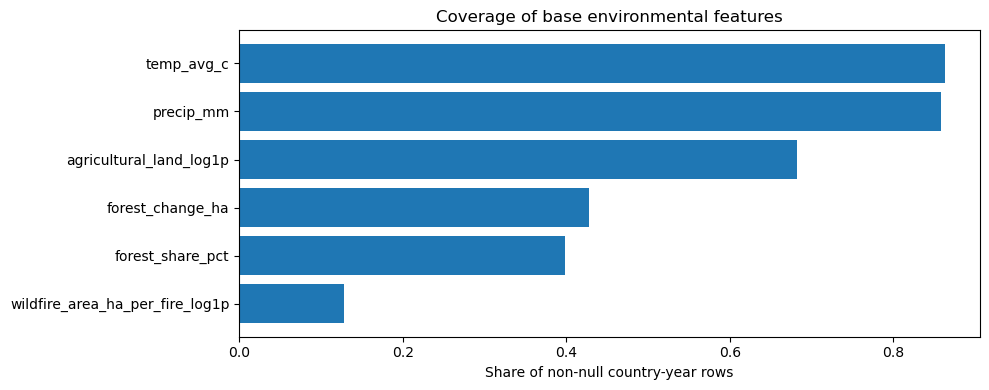

In [9]:
# =========================================================
# 6C. ENVIRONMENTAL COVERAGE DIAGNOSTICS
# =========================================================
base_coverage = feature_coverage_summary(env_panel, BASE_ENV_MODEL_FEATURES, group_col="country_norm")
display(base_coverage)

plt.figure(figsize=(10, 4))
plot_cov = base_coverage.sort_values("share_non_null", ascending=True)
plt.barh(plot_cov["feature"], plot_cov["share_non_null"])
plt.title("Coverage of base environmental features")
plt.xlabel("Share of non-null country-year rows")
plt.tight_layout()
plt.show()

Temperature and precipitation are the most robust global environmental predictors from a data availability perspective. Forest and especially wildfire variables require more caution, because their missingness may distort model comparison and reduce statistical power.

In [10]:
# =========================================================
# 6D. REPRESENTATIVE FEATURES BY CATEGORY
# =========================================================
CATEGORY_REPRESENTATIVE_FEATURES = {
    "temperature": "temp_avg_c_anomaly_country",
    "water": "precip_mm_anomaly_country",
    "habitat_cover": "forest_share_pct_change",
    "habitat_change": "forest_change_ha_roll3",
    "land_use": "agricultural_land_log1p_change",
    "disturbance": "wildfire_occurrence_roll3",
}

CATEGORY_REPRESENTATIVE_FEATURES = {
    k: v for k, v in CATEGORY_REPRESENTATIVE_FEATURES.items()
    if v in env_panel.columns
}

REPRESENTATIVE_ENV_FEATURES = list(CATEGORY_REPRESENTATIVE_FEATURES.values())

FULL_TRANSFORMED_ENV_FEATURES = [
    c for c in [
        "temp_avg_c_anomaly_country",
        "precip_mm_anomaly_country",
        "forest_share_pct_change",
        "forest_change_ha_roll3",
        "agricultural_land_log1p_change",
        "wildfire_occurrence",
        "wildfire_occurrence_roll3",
        "wildfire_shock",
    ]
    if c in env_panel.columns
]

print("Representative features:")
display(pd.DataFrame({
    "category": list(CATEGORY_REPRESENTATIVE_FEATURES.keys()),
    "feature": list(CATEGORY_REPRESENTATIVE_FEATURES.values())
}))

print("Full transformed feature pool:", FULL_TRANSFORMED_ENV_FEATURES)

Representative features:


,category,feature
0,temperature,temp_avg_c_anomaly_country
1,water,precip_mm_anomaly_country
2,habitat_cover,forest_share_pct_change
3,habitat_change,forest_change_ha_roll3
4,land_use,agricultural_land_log1p_change
5,disturbance,wildfire_occurrence_roll3


Full transformed feature pool: ['temp_avg_c_anomaly_country', 'precip_mm_anomaly_country', 'forest_share_pct_change', 'forest_change_ha_roll3', 'agricultural_land_log1p_change', 'wildfire_occurrence', 'wildfire_occurrence_roll3', 'wildfire_shock']


## 7. Load biodiversity and merge with the environmental panel

In [11]:
# =========================================================
# 7A. LOAD BIODIVERSITY DATA
# =========================================================
if not DEFAULT_BIODIVERSITY_PATH.exists():
    raise FileNotFoundError(
        "Biodiversity dataset not found at DEFAULT_BIODIVERSITY_PATH. "
        "Update the config cell before running."
    )

df_raw = pd.read_csv(DEFAULT_BIODIVERSITY_PATH)
print("Biodiversity raw shape:", df_raw.shape)
display(df_raw.head())

reference_columns = list(df_raw.columns)
year_columns = [c for c in reference_columns if str(c).isdigit()]
reference_columns_set = set(reference_columns)

static_numeric_features = ["latitude", "longitude"]
static_categorical_features = [
    "class",
    "family",
    "ipbes_subregion",
    "system_group",
    "t_realm",
    "t_biome",
    "units",
]
identifier_columns = ["id", "binomial", "common_name", "location", "country"]
leakage_columns = [
    "n_obs",
    "first_obs_year",
    "last_obs_year",
    "time_span",
    "n_gaps",
    "max_gap",
    "continuity_ratio",
    "zero_count",
    "zero_share",
    "years_since_last_obs",
]

static_numeric_features = [c for c in static_numeric_features if c in reference_columns_set]
static_categorical_features = [c for c in static_categorical_features if c in reference_columns_set]
identifier_columns = [c for c in identifier_columns if c in reference_columns_set]
leakage_columns = [c for c in leakage_columns if c in reference_columns_set]

bio_long = wide_to_long(df_raw, year_columns)
bio_long["country_norm"] = bio_long["country"].apply(normalize_country_name)

print("bio_long shape:", bio_long.shape)
display(bio_long.head())

Biodiversity raw shape: (49, 126)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group
0,27563,Gulo_gulo,0,1,"Kojola, I., S. Heikkinen, S. Mäntyniemi and T....",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Finland (inside reindeer areas),finland,Finland,Europe,Europe and Central Asia,Central and Western Europe,65.366353,28.516576,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.1429,5.4622,3.5247,3.2330,3.5247,3.5247,9.2437,8.1933,9.0686,13.8655,7.1429,9.6639,8.1933,5.8590,5.8824,14.6125,22.2689,20.7400,22.6891,37.3950,36.1345,50.5019,58.8235,37.3950,37.3950,54.2017,59.2437,57.9832,61.7647,92.437,74.3697,100.0000,1,NaN,32.0,1989.0,2020.0,32.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
1,27564,Gulo_gulo,0,1,"Kojola, I., S. Heikkinen, S. Mäntyniemi and T....",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Finland (outside reindeer areas),finland,Finland,Europe,Europe and Central Asia,Central and Western Europe,65.366353,28.516576,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0769,17.5824,18.6813,18.6813,24.1758,29.6703,31.8681,30.7692,38.4615,40.6593,37.3626,41.7582,46.1538,48.3516,72.5275,76.9231,92.3077,91.2088,90.1099,104.3956,105.4945,120.8791,136.2637,118.6813,135.1648,164.8352,200.0000,218.6813,236.2637,267.033,253.8462,327.4725,1,NaN,32.0,1989.0,2020.0,32.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
2,27565,Gulo_gulo,0,1,"Mattisson, J., L. Höglund and H. Brøseth (2020...",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Sweden,sweden,Sweden,Europe,Europe and Central Asia,Central and Western Europe,64.444593,15.165737,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,398.0000,380.0000,328.0000,319.0000,313.0000,343.0000,386.0000,431.0000,425.0000,444.0000,511.0000,575.0000,654.0000,669.0000,751.0000,715.0000,648.0000,587.0000,498.0000,523.0000,584.000,676.0000,687.0000,1,NaN,23.0,1998.0,2020.0,23.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
3,27566,Gulo_gulo,0,1,"Mattisson, J., L. Höglund and H. Brøseth (2020...",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Norway,norway,Norway,Europe,Europe and Central Asia,Central and Western Europe,64.867984,12.439186,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

bio_long shape: (1349, 60)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population,country_norm
1479,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,36.0,111105,3.610918,australia
1480,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,20.0,111106,3.044522,australia
1523,27730,Alces_americanus,0,1,Kluane National Park (2017) ‘Moose Survey Coun...,Mammalia,Artiodactyla,Cervidae,Alces,americanus,NaN,Moose,"Duke, Kluane National Park and Reserve, Yukon",canada,Canada,North America,Americas,North America,60.749785,-139.500032,1,terrestrial,Nearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,adult individuals (bulls and cows),1,NaN,36.0,1981.0,2020.0,40.0,4.0,1.0,0.90000,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,81.0,27730,4.406719,canada
1528,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,21.0,111105,3.091042,australia
1529,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,28.0,111106,3.367296,australia


In [12]:
# =========================================================
# 7B. COUNTRY OVERLAP CHECK
# =========================================================
bio_countries = set(bio_long["country_norm"].dropna().unique())
env_countries = set(env_panel["country_norm"].dropna().unique())

only_bio = sorted(bio_countries - env_countries)
only_env = sorted(env_countries - bio_countries)

print("Countries only in biodiversity:", len(only_bio))
print("Countries only in environment:", len(only_env))

display(pd.DataFrame({"country_only_in_biodiversity": only_bio[:50]}))
display(pd.DataFrame({"country_only_in_environment": only_env[:50]}))

Countries only in biodiversity: 0
Countries only in environment: 237


,country_only_in_biodiversity


,country_only_in_environment
0,afghanistan
1,albania
2,algeria
3,american samoa
4,andorra
5,angola
6,anguilla
7,antigua and barbuda
8,argentina
9,armenia


In [13]:
# =========================================================
# 7C. MERGE BIODIVERSITY + ENVIRONMENT
# =========================================================
model_long_pre_lags = bio_long.merge(
    env_panel,
    on=["country_norm", "Year"],
    how="left",
)

print("Merged pre-lag shape:", model_long_pre_lags.shape)
display(feature_coverage_summary(model_long_pre_lags, BASE_ENV_MODEL_FEATURES + REPRESENTATIVE_ENV_FEATURES, group_col="series_id"))
display(model_long_pre_lags.head())

Merged pre-lag shape: (1349, 96)


,feature,non_null_rows,share_non_null,groups_with_data,year_min_with_data,year_max_with_data,note
4,agricultural_land_log1p,1349,1.000000,49,1980,2020,
10,agricultural_land_log1p_change,1349,1.000000,49,1980,2020,
1,precip_mm,1349,1.000000,49,1980,2020,
7,precip_mm_anomaly_country,1349,1.000000,49,1980,2020,
0,temp_avg_c,1349,1.000000,49,1980,2020,
6,temp_avg_c_anomaly_country,1349,1.000000,49,1980,2020,
11,wildfire_occurrence_roll3,1349,1.000000,49,1980,2020,
2,forest_share_pct,1312,0.972572,49,1990,2020,
3,forest_change_ha,1297,0.961453,49,1991,2020,
8,forest_share_pct_change,1297,0.961453,49,1991,2020,


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population,country_norm,temp_avg_c,precip_mm,forest_share_pct,forest_change_ha,agricultural_land_ha,agricultural_land_log1p,wildfire_area_ha_per_fire,wildfire_area_ha_per_fire_log1p,temp_avg_c_lag1_country,temp_avg_c_change,temp_avg_c_roll3,temp_avg_c_anomaly_country,precip_mm_lag1_country,precip_mm_change,precip_mm_roll3,precip_mm_anomaly_country,forest_share_pct_lag1_country,forest_share_pct_change,forest_share_pct_roll3,forest_share_pct_anomaly_country,forest_change_ha_lag1_country,forest_change_ha_change,forest_change_ha_roll3,forest_change_ha_anomaly_country,agricultural_land_log1p_lag1_country,agricultural_land_log1p_change,agricultural_land_log1p_roll3,agricultural_land_log1p_anomaly_country,wildfire_area_ha_per_fire_log1p_lag1_country,wildfire_area_ha_per_fire_log1p_change,wildfire_area_ha_per_fire_log1p_roll3,wildfire_area_ha_per_fire_log1p_anomaly_country,wildfire_occurrence,wildfire_occurrence_roll3,wildfire_shock,forest_change_sign
0,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,36.0,111105,3.610918,australia,22.476896,411.99690,NaN,NaN,495638000.0,20.021356,NaN,NaN,22.050299,0.426597,21.957197,0.494948,443.9052,-31.90830,453.536877,-34.895090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.016502,0.004854,20.020049,0.111083,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
1,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,20.0,111106,3.044522,australia,22.476896,411.99690,NaN,NaN,495638000.0,20.021356,NaN,NaN,22.050299,0.426597,21.957197,0.494948,443.9052,-31.90830,453.536877,-34.895090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.016502,0.004854,20.020049,0.111083,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
2,27730,Alces_americanus,0,1,Kluane National Park (2017) ‘Moose Survey Coun...,Mammalia,Artiodactyla,Cervidae,Alces,americanus,NaN,Moose,"Duke, Kluane National Park and Reserve, Yukon",canada,Canada,North America,Americas,North America,60.749785,-139.500032,1,terrestrial,Nearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,adult individuals (bulls and cows),1,NaN,36.0,1981.0,2020.0,40.0,4.0,1.0,0.90000,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,81.0,27730,4.406719,canada,-2.742507,645.53790,NaN,NaN,61290000.0,17.931127,NaN,NaN,-4.342841,1.600334,-4.009207,1.499136,664.9655,-19.42760,653.708083,-9.233423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.937146,-0.006019,17.937161,0.006720,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
3,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Ma

In [14]:
# =========================================================
# 7D. BUILD LAGGED MODEL FRAME
# =========================================================
model_long = add_lag_features(model_long_pre_lags, n_lags=N_LAGS)

print("Rows before lags:", len(model_long_pre_lags))
print("Rows after lags:", len(model_long))
display(model_long.head())

Rows before lags: 1349
Rows after lags: 1153


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population,country_norm,temp_avg_c,precip_mm,forest_share_pct,forest_change_ha,agricultural_land_ha,agricultural_land_log1p,wildfire_area_ha_per_fire,wildfire_area_ha_per_fire_log1p,temp_avg_c_lag1_country,temp_avg_c_change,temp_avg_c_roll3,temp_avg_c_anomaly_country,precip_mm_lag1_country,precip_mm_change,precip_mm_roll3,precip_mm_anomaly_country,forest_share_pct_lag1_country,forest_share_pct_change,forest_share_pct_roll3,forest_share_pct_anomaly_country,forest_change_ha_lag1_country,forest_change_ha_change,forest_change_ha_roll3,forest_change_ha_anomaly_country,agricultural_land_log1p_lag1_country,agricultural_land_log1p_change,agricultural_land_log1p_roll3,agricultural_land_log1p_anomaly_country,wildfire_area_ha_per_fire_log1p_lag1_country,wildfire_area_ha_per_fire_log1p_change,wildfire_area_ha_per_fire_log1p_roll3,wildfire_area_ha_per_fire_log1p_anomaly_country,wildfire_occurrence,wildfire_occurrence_roll3,wildfire_shock,forest_change_sign,lag_1,lag_2,lag_3,lag_4,prev_year,year_gap_from_prev,rolling_mean_3,rolling_std_3,population_difference,population_growth_rate
22,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Burramyidae,Burramys,parvus,NaN,Mountain Pygmy-possum,Victorian Alps,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.208994,146.845252,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: occupancy (# presences/# surveys = tra...,1,NaN,39.0,1982.0,2020.0,39.0,0.0,0.0,1.0,1.0,0.025641,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1986,1.285714,110261,0.826679,australia,21.988586,400.56122,NaN,NaN,468541000.0,19.965134,NaN,NaN,21.955000,0.033586,21.773666,0.006638,412.62817,-12.06695,456.024297,-46.33077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.003345,-0.038211,19.990449,0.054861,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1.190476,0.714286,0.000000,1.111111,1985.0,1.0,2.166667,1.312996,0.476190,0.666667
24,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Burramyidae,Burramys,parvus,NaN,Mountain Pygmy-possum,Victorian Alps,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.208994,146.845252,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: occupancy (# presences/# surveys = tra...,1,NaN,39.0,1982.0,2020.0,39.0,0.0,0.0,1.0,1.0,0.025641,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1987,4.000000,110261,1.609438,australia,21.950060,469.45460,NaN,NaN,471020000.0,19.970411,NaN,NaN,21.988586,-0.038526,21.964549,-0.031888,400.56122,68.89338,427.547997,22.56261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.965134,0.005277,19.979630,0.060138,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1.285714,1.190476,0.714286,0.000000,1986.0,1.0,1.645833,0.815699,0.095238,0.080000
28,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Burramyidae,Burramys,parvus,NaN,Mountain Pygmy-possum,Victorian Alps,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.208994,146.845252,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: occupancy (# presences/# surveys = tra...,1,NaN,39.0,1982.0,2020.0,39.0,0.0,0.0,1.0,1.0,0.025641,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,

## 8. Define a clean experiment matrix

Key principle:
- **forecast baseline** and **forecast + environment** are run on the **same lagged frame**,
- so any difference is due to feature information, not to different rows.

In [15]:
# =========================================================
# 8A. EXPERIMENT DEFINITIONS
# =========================================================
EXPERIMENTS = {
    "forecast_baseline": {
        "frame_name": "lagged",
        "include_lags": True,
        "env_features": [],
        "include_static_metadata": True,
        "description": "Lag-based biodiversity forecasting baseline",
    },
    "forecast_plus_env_representative": {
        "frame_name": "lagged",
        "include_lags": True,
        "env_features": REPRESENTATIVE_ENV_FEATURES,
        "include_static_metadata": True,
        "description": "Baseline + one transformed environmental feature per category",
    },
    "forecast_plus_env_full_transformed": {
        "frame_name": "lagged",
        "include_lags": True,
        "env_features": FULL_TRANSFORMED_ENV_FEATURES,
        "include_static_metadata": True,
        "description": "Baseline + richer transformed environmental block",
    },
    "environment_only_representative": {
        "frame_name": "pre_lag",
        "include_lags": False,
        "env_features": REPRESENTATIVE_ENV_FEATURES,
        "include_static_metadata": True,
        "description": "No biodiversity lags; metadata + representative environment block",
    },
}

# Category ablations: one category at a time on top of the lag baseline
for category, feature_name in CATEGORY_REPRESENTATIVE_FEATURES.items():
    EXPERIMENTS[f"forecast_plus_{category}"] = {
        "frame_name": "lagged",
        "include_lags": True,
        "env_features": [feature_name],
        "include_static_metadata": True,
        "description": f"Baseline + {category}",
    }

display(pd.DataFrame([
    {
        "experiment": k,
        "frame_name": v["frame_name"],
        "include_lags": v["include_lags"],
        "n_env_features": len(v["env_features"]),
        "description": v["description"],
    }
    for k, v in EXPERIMENTS.items()
]))

,experiment,frame_name,include_lags,n_env_features,description
0,forecast_baseline,lagged,True,0,Lag-based biodiversity forecasting baseline
1,forecast_plus_env_representative,lagged,True,6,Baseline + one transformed environmental featu...
2,forecast_plus_env_full_transformed,lagged,True,8,Baseline + richer transformed environmental block
3,environment_only_representative,pre_lag,False,6,No biodiversity lags; metadata + representativ...
4,forecast_plus_temperature,lagged,True,1,Baseline + temperature
5,forecast_plus_water,lagged,True,1,Baseline + water
6,forecast_plus_habitat_cover,lagged,True,1,Baseline + habitat_cover
7,forecast_plus_habitat_change,lagged,True,1,Baseline + habitat_change
8,forecast_plus_land_use,lagged,True,1,Baseline + land_use
9,forecast_plus_disturbance,lagged,True,1,Baseline + disturbance


In [16]:
# =========================================================
# 8B. RUN GLOBAL EXPERIMENTS
# =========================================================
all_results = []
all_importances = []
fitted_global_models = {}

FRAME_LOOKUP = {
    "pre_lag": model_long_pre_lags,
    "lagged": model_long,
}

for exp_name, exp_cfg in EXPERIMENTS.items():
    frame = FRAME_LOOKUP[exp_cfg["frame_name"]].copy()

    feature_bundle = build_feature_columns(
        df=frame,
        include_lags=exp_cfg["include_lags"],
        env_features=exp_cfg["env_features"],
        include_static_metadata=exp_cfg["include_static_metadata"],
        static_numeric_features=static_numeric_features,
        static_categorical_features=static_categorical_features,
        n_lags=N_LAGS,
    )

    results_df_i, importance_tables_i, fitted_models_i = run_model_comparison(
        df=frame,
        feature_columns=feature_bundle["feature_columns"],
        categorical_features=feature_bundle["categorical_features"],
        label=exp_name,
    )

    all_results.append(results_df_i)
    all_importances.extend(list(importance_tables_i.values()))
    fitted_global_models[exp_name] = {
        "frame": frame,
        "feature_bundle": feature_bundle,
        "models": fitted_models_i,
        "description": exp_cfg["description"],
    }

results_df = pd.concat(all_results, ignore_index=True).sort_values(["NMAE", "feature_set", "model"])
importance_df = pd.concat(all_importances, ignore_index=True)

display(results_df)

,feature_set,model,MAE,RMSE,NMAE,WAPE,sMAPE,n_train,n_test,test_year_start,test_year_end,best_params
24,forecast_plus_land_use,RandomForest,5.191747,15.007047,0.149702,0.149702,0.886675,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le..."
0,forecast_baseline,RandomForest,5.198643,14.981588,0.149901,0.149901,0.902839,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le..."
21,forecast_plus_habitat_change,RandomForest,5.244594,15.151510,0.151226,0.151226,0.894213,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le..."
15,forecast_plus_water,RandomForest,5.246921,15.036082,0.151293,0.151293,0.934931,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le..."
27,forecast_plus_disturbance,RandomForest,5.261110,15.148319,0.151702,0.151702,0.902643,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le..."
12,forecast_plus_temperature,RandomForest,5.343484,15.392387,0.154077,0.154077,0.917282,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le..."
3,forecast_plus_env_representative,RandomForest,5.361862,15.357493,0.154607,0.154607,0.924369,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le..."
6,forecast_plus_env_full_transformed,RandomForest,5.435157,15.554769,0.156721,0.156721,0.927208,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le..."
18,forecast_plus_habitat_cover,RandomForest,5.435718,15.447396,0.156737,0.156737,0.900712,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le..."
2,forecast_baseline,XGBoost,5.451747,15.152550,0.157199,0.157199,0.881223,909,244,2016,2020,"{'model__colsample_bytree': 0.8, 'model__learn..."


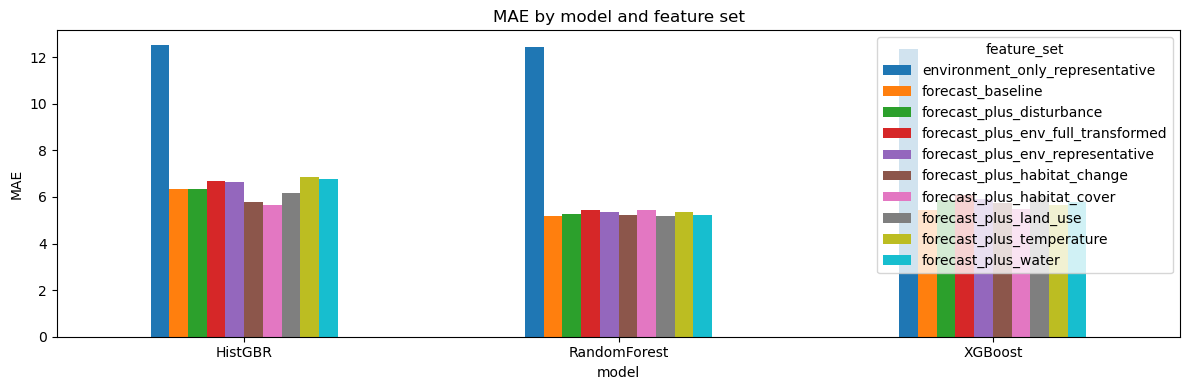

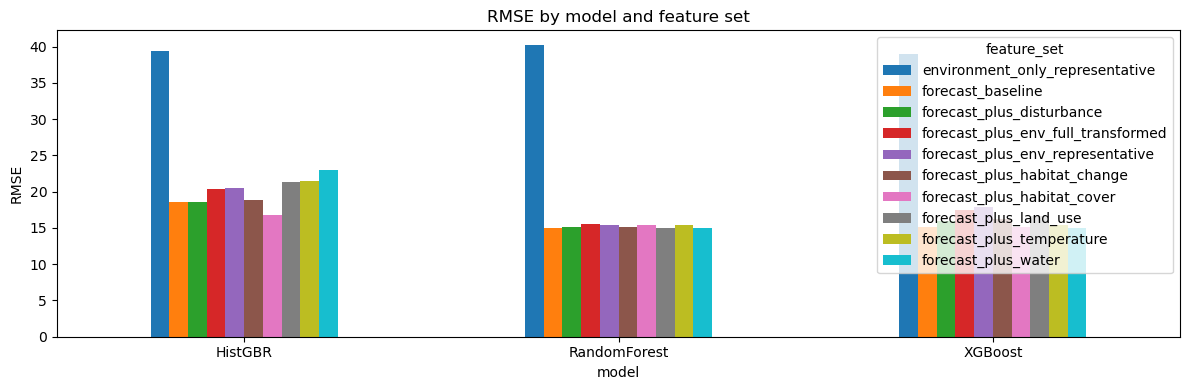

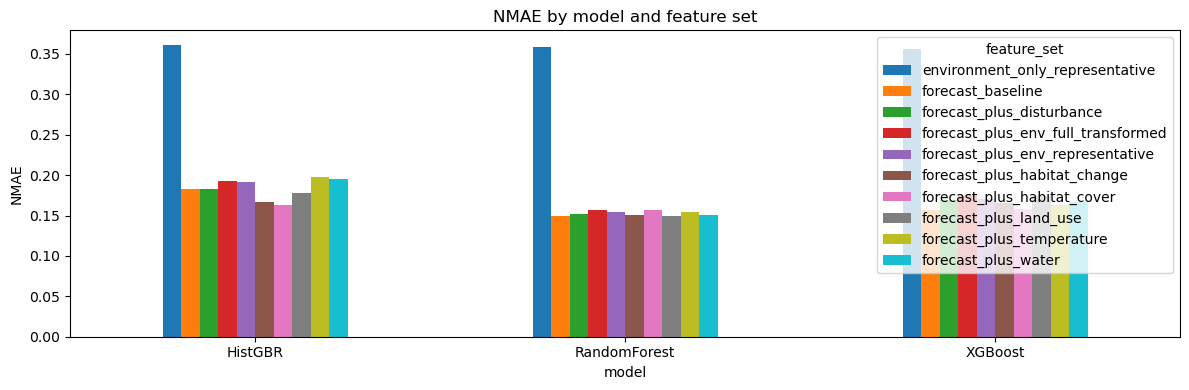

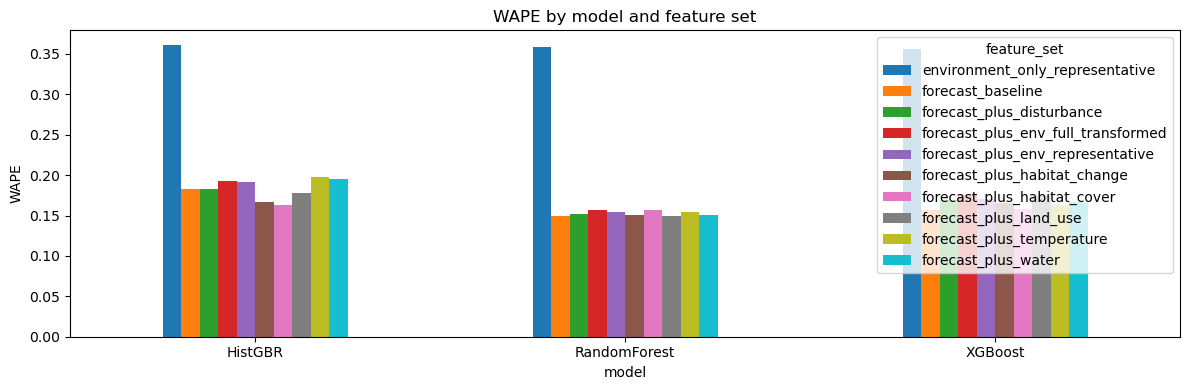

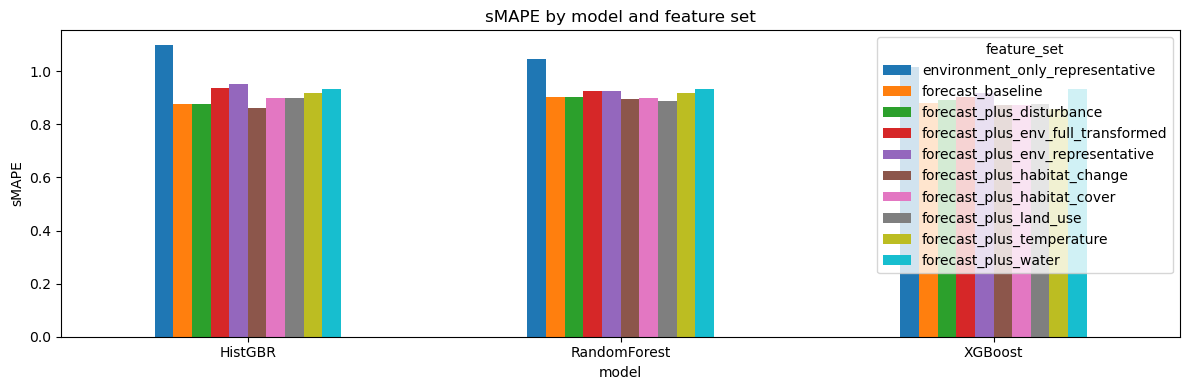

In [17]:
# =========================================================
# 8C. PERFORMANCE VISUALS
# =========================================================
for metric in ["MAE", "RMSE", "NMAE", "WAPE", "sMAPE"]:
    pivot = results_df.pivot(index="model", columns="feature_set", values=metric)
    ax = pivot.plot(kind="bar", figsize=(12, 4), rot=0, title=f"{metric} by model and feature set")
    ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()

,feature,importance_mean,importance_std,feature_set,model
159,lag_1,1.203195e+00,6.709371e-02,forecast_plus_env_full_transformed,HistGBR
160,lag_2,2.662371e-02,5.119882e-03,forecast_plus_env_full_transformed,HistGBR
161,precip_mm_anomaly_country,9.614348e-03,6.848897e-03,forecast_plus_env_full_transformed,HistGBR
162,lag_4,8.598788e-03,1.473961e-03,forecast_plus_env_full_transformed,HistGBR
163,agricultural_land_log1p_change,5.770275e-03,2.267770e-03,forecast_plus_env_full_transformed,HistGBR
164,lag_3,4.601044e-03,2.345756e-03,forecast_plus_env_full_transformed,HistGBR
165,population_difference,1.918616e-03,1.461442e-03,forecast_plus_env_full_transformed,HistGBR
166,longitude,8.885091e-04,1.239859e-03,forecast_plus_env_full_transformed,HistGBR
167,forest_change_ha_roll3,8.122460e-04,1.198970e-04,forecast_plus_env_full_transformed,HistGBR
168,rolling_std_3,7.844113e-04,2.078562e-03,forecast_plus_env_full_transformed,HistGBR


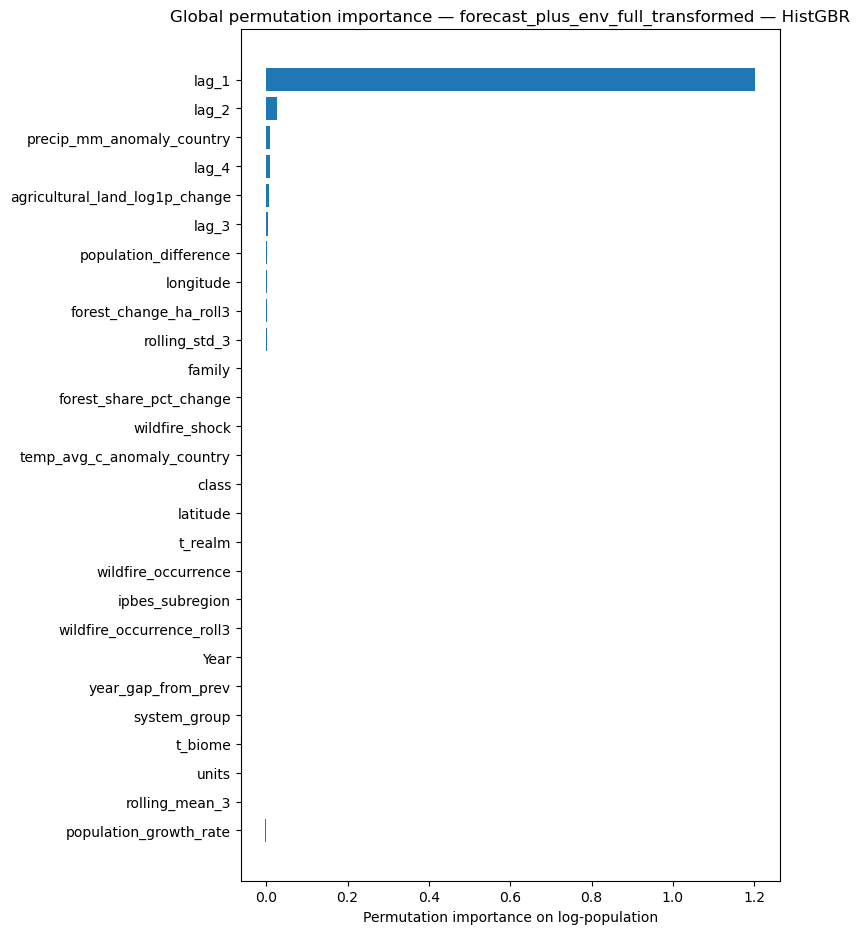

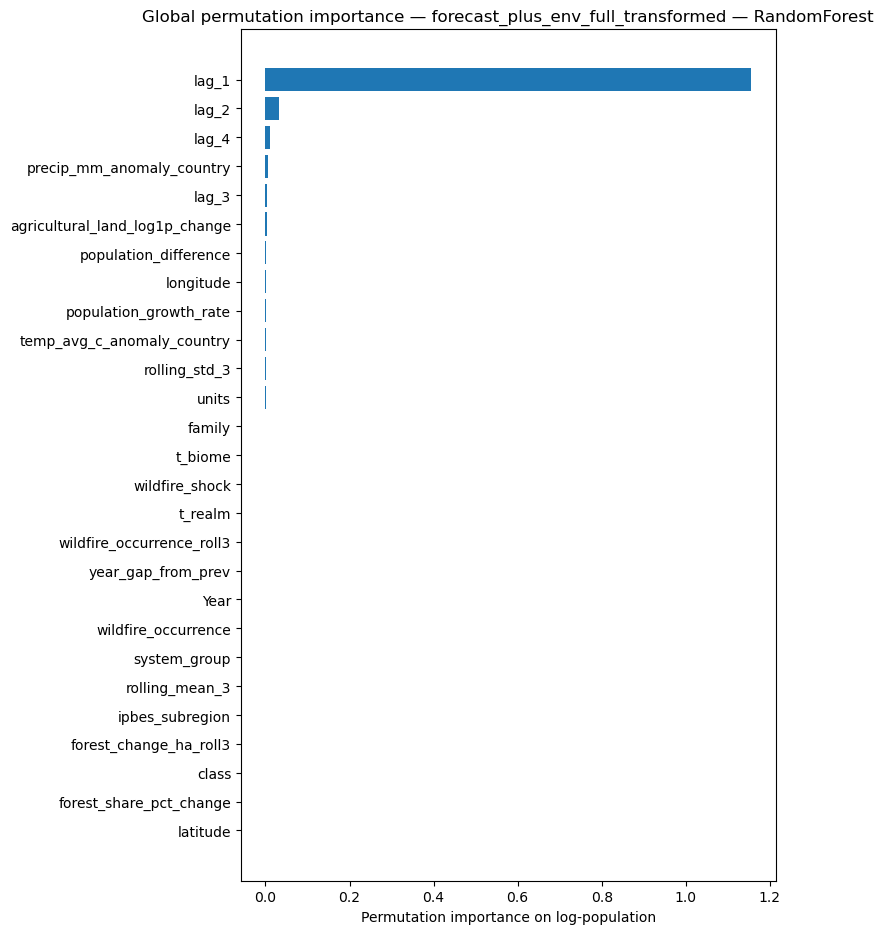

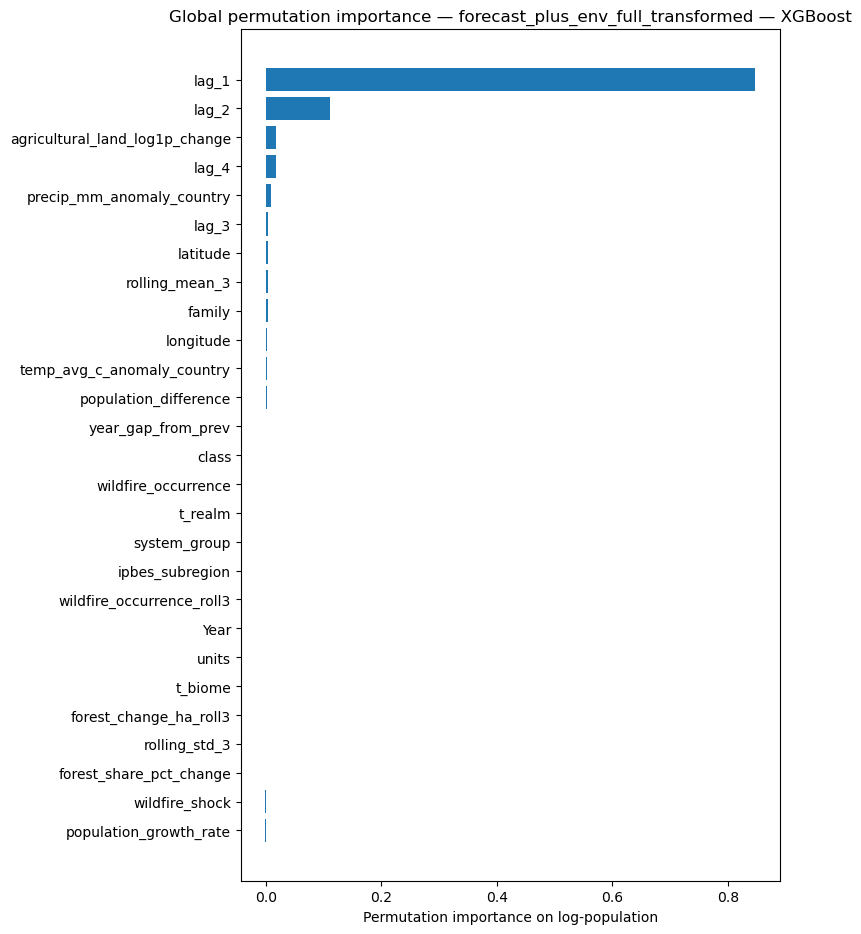

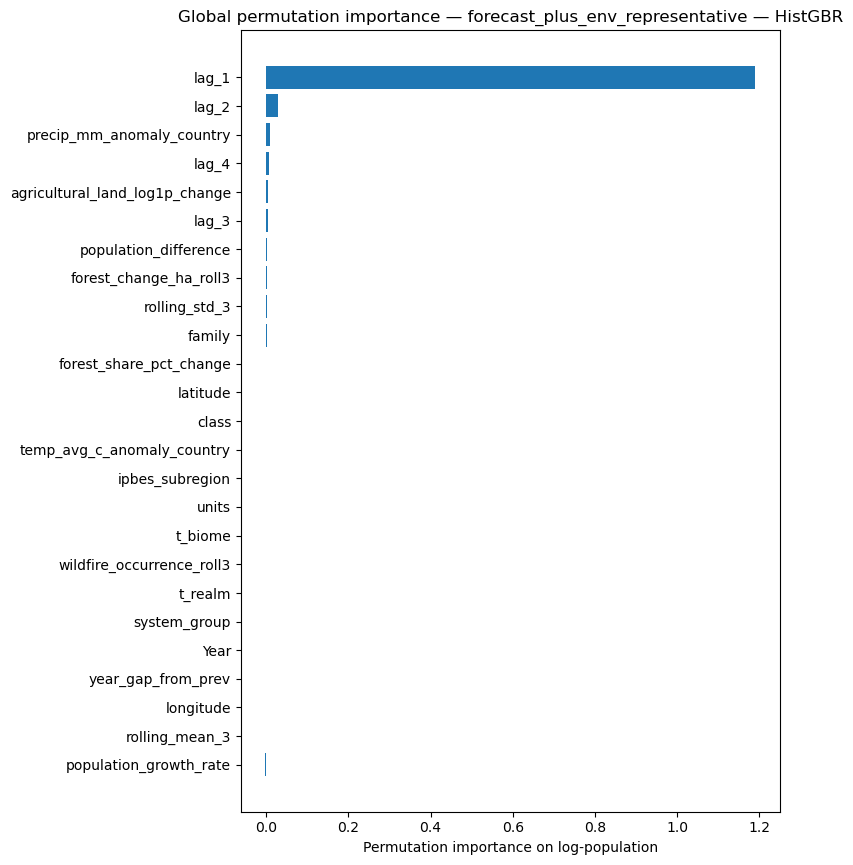

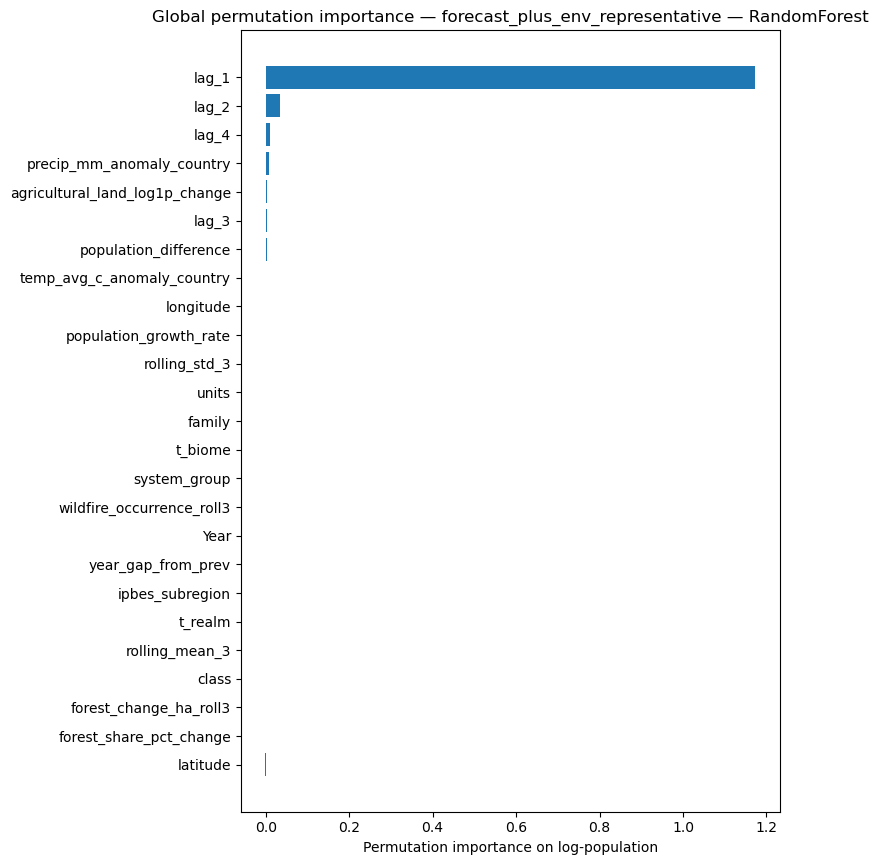

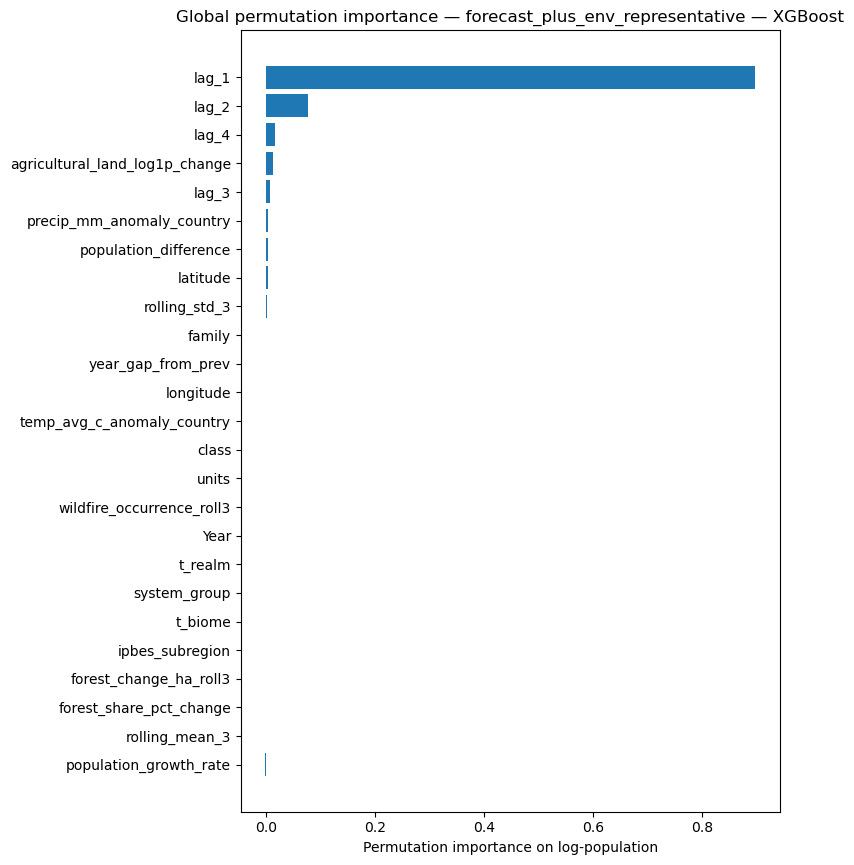

In [18]:
# =========================================================
# 8D. GLOBAL ENVIRONMENTAL IMPORTANCE
# =========================================================
global_env_importance = (
    importance_df[
        importance_df["feature_set"].isin(["forecast_plus_env_representative", "forecast_plus_env_full_transformed"])
    ]
    .sort_values(["feature_set", "model", "importance_mean"], ascending=[True, True, False])
)

display(global_env_importance)

for exp_name in global_env_importance["feature_set"].unique():
    for model_name in global_env_importance.loc[global_env_importance["feature_set"] == exp_name, "model"].unique():
        plot_df = (
            global_env_importance[
                (global_env_importance["feature_set"] == exp_name) &
                (global_env_importance["model"] == model_name)
            ]
            .sort_values("importance_mean", ascending=True)
        )

        plt.figure(figsize=(8, max(4, len(plot_df) * 0.35)))
        plt.barh(plot_df["feature"], plot_df["importance_mean"])
        plt.title(f"Global permutation importance — {exp_name} — {model_name}")
        plt.xlabel("Permutation importance on log-population")
        plt.tight_layout()
        plt.show()

## 9. Optional residual view

This helper is here because environmental variables can be useful even when they barely move the global forecast metric.

It asks:
> what part of the baseline error can the environmental block still explain?

In [19]:
# =========================================================
# 9A. OPTIONAL RESIDUAL HELPER
# =========================================================
def build_residual_diagnostic_table(results_df):
    forecast_rows = results_df[results_df["feature_set"].str.startswith("forecast_")].copy()
    baseline_best = forecast_rows[forecast_rows["feature_set"] == "forecast_baseline"].sort_values("NMAE").head(1)
    augmented_rows = forecast_rows[forecast_rows["feature_set"] != "forecast_baseline"].copy()

    if baseline_best.empty or augmented_rows.empty:
        return pd.DataFrame()

    baseline_nmae = baseline_best["NMAE"].iloc[0]
    augmented_rows["delta_vs_baseline_nmae"] = augmented_rows["NMAE"] - baseline_nmae
    return augmented_rows.sort_values(["delta_vs_baseline_nmae", "NMAE"])

display(build_residual_diagnostic_table(results_df))

,feature_set,model,MAE,RMSE,NMAE,WAPE,sMAPE,n_train,n_test,test_year_start,test_year_end,best_params,delta_vs_baseline_nmae
24,forecast_plus_land_use,RandomForest,5.191747,15.007047,0.149702,0.149702,0.886675,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le...",-0.000199
21,forecast_plus_habitat_change,RandomForest,5.244594,15.151510,0.151226,0.151226,0.894213,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le...",0.001325
15,forecast_plus_water,RandomForest,5.246921,15.036082,0.151293,0.151293,0.934931,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le...",0.001392
27,forecast_plus_disturbance,RandomForest,5.261110,15.148319,0.151702,0.151702,0.902643,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le...",0.001801
12,forecast_plus_temperature,RandomForest,5.343484,15.392387,0.154077,0.154077,0.917282,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le...",0.004176
3,forecast_plus_env_representative,RandomForest,5.361862,15.357493,0.154607,0.154607,0.924369,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le...",0.004706
6,forecast_plus_env_full_transformed,RandomForest,5.435157,15.554769,0.156721,0.156721,0.927208,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le...",0.006820
18,forecast_plus_habitat_cover,RandomForest,5.435718,15.447396,0.156737,0.156737,0.900712,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le...",0.006836
20,forecast_plus_habitat_cover,XGBoost,5.471779,15.149702,0.157776,0.157776,0.874241,909,244,2016,2020,"{'model__colsample_bytree': 1.0, 'model__learn...",0.007876
14,forecast_plus_temperature,XGBoost,5.664610,15.418361,0.163337,0.163337,0.859439,909,244,2016,2020,"{'model__colsample_bytree': 1.0, 'model__learn...",0.013436


## 10. Single-population driver model

This section deliberately removes:
- biodiversity lag features,
- non-climatic metadata.

Goal:
- identify the **top environmental drivers** for one population,
- keep the interpretation clean,
- make the final application function easier to understand.

In [20]:
# =========================================================
# 10A. LOCAL DRIVER MODEL HELPERS
# =========================================================
def choose_local_series(df, feature_cols, min_rows=12):
    rows = []
    for series_id, g in df.groupby("series_id"):
        if len(g) < min_rows:
            continue
        coverage = g[feature_cols].notna().mean().mean() if feature_cols else 0
        rows.append({
            "series_id": series_id,
            "rows": len(g),
            "mean_feature_coverage": coverage,
            "last_year": g["Year"].max(),
        })

    candidates = pd.DataFrame(rows)
    if candidates.empty:
        raise ValueError("No series satisfies the minimum length requirement.")
    return candidates.sort_values(
        ["mean_feature_coverage", "rows", "last_year"],
        ascending=[False, False, False],
    ).reset_index(drop=True)


def get_series_metadata(df, series_id):
    cols = [
        "series_id", "id", "binomial", "common_name", "class", "family",
        "country", "country_norm", "location", "units", "t_realm", "t_biome",
        "ipbes_subregion"
    ]
    cols = [c for c in cols if c in df.columns]

    meta = (
        df[df["series_id"] == series_id][cols]
        .drop_duplicates()
        .head(1)
        .T
        .reset_index()
    )
    meta.columns = ["field", "value"]
    return meta


def fit_local_population_driver_model(df, series_id, feature_columns, test_years=4):
    local_df = (
        df[df["series_id"] == series_id]
        .sort_values("Year")
        .dropna(subset=["Population", "log_population"])
        .copy()
        .reset_index(drop=True)
    )

    if len(local_df) <= test_years + 4:
        raise ValueError("Selected population has too few rows for a local temporal split.")

    train_df, test_df, test_year_values = temporal_split(local_df, test_years=test_years)

    X_train = train_df[feature_columns].copy()
    y_train = train_df["log_population"].copy()
    X_test = test_df[feature_columns].copy()
    y_test = test_df["Population"].copy()
    y_test_log = test_df["log_population"].copy()

    preprocessor = make_preprocessor(feature_columns, [])
    model_grid = get_model_grid(preprocessor)

    rows = []
    fitted = {}
    importances = {}

    cv = build_internal_temporal_cv(train_df, val_years=min(2, test_years))

    for model_name, (pipeline, param_grid) in model_grid.items():
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        grid.fit(X_train, y_train)

        estimator = grid.best_estimator_
        pred_log = estimator.predict(X_test)
        pred_population = np.clip(np.expm1(pred_log), a_min=0, a_max=None)

        metrics = evaluate_regression(y_test.to_numpy(), pred_population)
        rows.append({
            "model": model_name,
            **metrics,
            "test_year_start": min(test_year_values),
            "test_year_end": max(test_year_values),
            "best_params": str(grid.best_params_),
        })

        perm = permutation_importance(
            estimator,
            X_test,
            y_test_log,
            n_repeats=8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        imp_df = pd.DataFrame({
            "feature": feature_columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
            "model": model_name,
        }).sort_values("importance_mean", ascending=False)

        fitted[model_name] = {
            "estimator": estimator,
            "train_df": train_df,
            "test_df": test_df,
            "local_df": local_df,
            "pred_log": pred_log,
            "pred_population": pred_population,
        }
        importances[model_name] = imp_df

    result_df = pd.DataFrame(rows).sort_values("NMAE").reset_index(drop=True)
    return result_df, fitted, importances


def directional_what_if_score(estimator, X_ref, feature):
    X_low = X_ref.copy()
    X_high = X_ref.copy()

    q10 = X_ref[feature].quantile(0.10)
    q90 = X_ref[feature].quantile(0.90)

    X_low[feature] = q10
    X_high[feature] = q90

    pred_low = np.expm1(estimator.predict(X_low))
    pred_high = np.expm1(estimator.predict(X_high))
    return float(np.mean(pred_high - pred_low))

In [21]:
# =========================================================
# 10B. RUN LOCAL DRIVER ANALYSIS FOR AN EXAMPLE SERIES
# =========================================================
LOCAL_DRIVER_FEATURES = [c for c in REPRESENTATIVE_ENV_FEATURES if c in model_long_pre_lags.columns]

local_series_candidates = choose_local_series(
    model_long_pre_lags,
    feature_cols=LOCAL_DRIVER_FEATURES,
    min_rows=LOCAL_MIN_SERIES_ROWS,
)

EXAMPLE_SERIES_ID = local_series_candidates.iloc[0]["series_id"]

print("Example series selected for local driver analysis:")
print(EXAMPLE_SERIES_ID)
display(local_series_candidates.head(10))
display(get_series_metadata(model_long_pre_lags, EXAMPLE_SERIES_ID))

local_results_df, local_fitted_models, local_importance_tables = fit_local_population_driver_model(
    df=model_long_pre_lags,
    series_id=EXAMPLE_SERIES_ID,
    feature_columns=LOCAL_DRIVER_FEATURES,
    test_years=LOCAL_TEST_YEARS,
)

display(local_results_df)

LOCAL_BEST_MODEL = local_results_df.iloc[0]["model"]
best_local_estimator = local_fitted_models[LOCAL_BEST_MODEL]["estimator"]
best_local_full_df = local_fitted_models[LOCAL_BEST_MODEL]["local_df"]
best_local_test_df = local_fitted_models[LOCAL_BEST_MODEL]["test_df"]

local_driver_table = local_importance_tables[LOCAL_BEST_MODEL].copy()
local_driver_table["directional_q90_minus_q10_effect"] = local_driver_table["feature"].apply(
    lambda f: directional_what_if_score(
        estimator=best_local_estimator,
        X_ref=best_local_full_df[LOCAL_DRIVER_FEATURES].copy(),
        feature=f,
    )
)
top3_local_drivers = local_driver_table.head(3).copy()

display(top3_local_drivers)

Example series selected for local driver analysis:
120335


,series_id,rows,mean_feature_coverage,last_year
0,120335,29,1.0,2020
1,120267,28,1.0,2020
2,120305,28,1.0,2020
3,120325,28,1.0,2020
4,120331,28,1.0,2020
5,120332,28,1.0,2020
6,120321,27,1.0,2020
7,120328,27,1.0,2020
8,120337,27,1.0,2020
9,120339,27,1.0,2020


,field,value
0,series_id,120335
1,id,120335
2,binomial,Leipoa_ocellata
3,common_name,Malleefowl
4,class,Aves
5,family,Megapodiidae
6,country,australia
7,country_norm,australia
8,location,Lowan Mallee
9,units,proxy: breeding pairs


,model,MAE,RMSE,NMAE,WAPE,sMAPE,test_year_start,test_year_end,best_params
0,HistGBR,1.500000,1.934627,0.500000,0.500000,0.660534,2017,2020,"{'model__learning_rate': 0.05, 'model__max_dep..."
1,XGBoost,1.660908,1.962551,0.553636,0.553636,0.796794,2017,2020,"{'model__colsample_bytree': 0.8, 'model__learn..."
2,RandomForest,1.698826,2.179285,0.566275,0.566275,0.821617,2017,2020,"{'model__max_depth': 8, 'model__min_samples_le..."


,feature,importance_mean,importance_std,model,directional_q90_minus_q10_effect
0,temp_avg_c_anomaly_country,0.0,0.0,HistGBR,0.0
1,precip_mm_anomaly_country,0.0,0.0,HistGBR,0.0
2,forest_share_pct_change,0.0,0.0,HistGBR,0.0


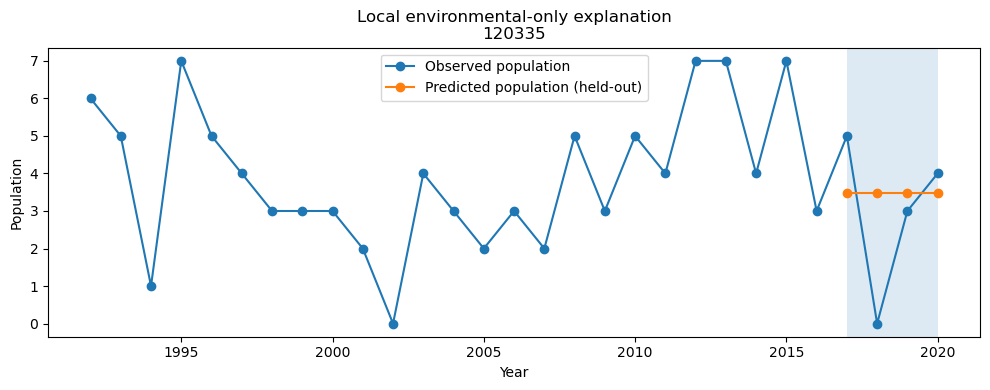

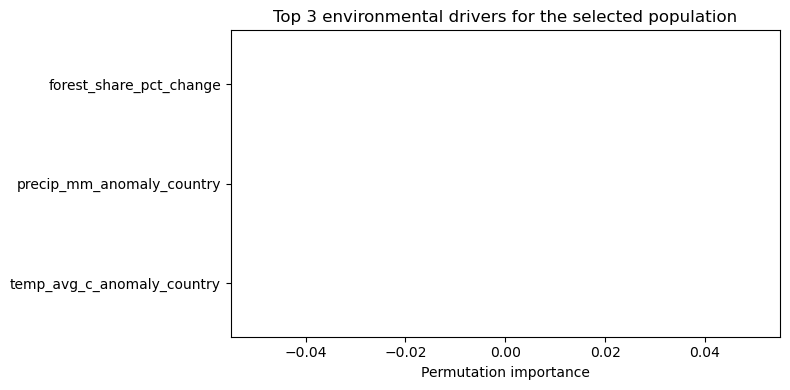

In [22]:
# =========================================================
# 10C. LOCAL DRIVER VISUALS
# =========================================================
local_test_plot = best_local_test_df.copy()
local_test_plot["pred_log"] = best_local_estimator.predict(local_test_plot[LOCAL_DRIVER_FEATURES])
local_test_plot["pred_population"] = np.clip(np.expm1(local_test_plot["pred_log"]), a_min=0, a_max=None)

plt.figure(figsize=(10, 4))
plt.plot(best_local_full_df["Year"], best_local_full_df["Population"], marker="o", label="Observed population")
plt.plot(local_test_plot["Year"], local_test_plot["pred_population"], marker="o", label="Predicted population (held-out)")
plt.axvspan(local_test_plot["Year"].min(), local_test_plot["Year"].max(), alpha=0.15)
plt.title(f"Local environmental-only explanation\n{EXAMPLE_SERIES_ID}")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.tight_layout()
plt.show()

plot_df = top3_local_drivers.sort_values("importance_mean", ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.title("Top 3 environmental drivers for the selected population")
plt.xlabel("Permutation importance")
plt.tight_layout()
plt.show()

## 11. Application-ready helper functions

This is the section you can later turn into an API endpoint.

The main function is:

```python
analyze_population(
    population_id=...,
    horizon_years=...,
)
```

It returns:
- metadata,
- forecast dataframe,
- top 3 climatic / anthropogenic drivers,
- IUCN lookup output when available.

In [23]:
# =========================================================
# 11A. BEST GLOBAL FORECASTER SELECTION + FINAL REFIT
# =========================================================
forecast_results = results_df[results_df["feature_set"].str.startswith("forecast_")].copy()
best_forecast_row = forecast_results.sort_values("NMAE").iloc[0]

BEST_FORECAST_EXPERIMENT = best_forecast_row["feature_set"]
BEST_FORECAST_MODEL_NAME = best_forecast_row["model"]

print("Best forecasting setup selected for final population forecasting:")
display(best_forecast_row.to_frame().T)

best_bundle = fitted_global_models[BEST_FORECAST_EXPERIMENT]
best_model_artifacts = best_bundle["models"][BEST_FORECAST_MODEL_NAME]

final_global_forecaster = refit_model_on_full_frame(
    df=best_bundle["frame"],
    feature_columns=best_bundle["feature_bundle"]["feature_columns"],
    categorical_features=best_bundle["feature_bundle"]["categorical_features"],
    model_name=BEST_FORECAST_MODEL_NAME,
    best_params=best_model_artifacts["best_params"],
)

FINAL_FORECAST_FEATURE_COLUMNS = best_bundle["feature_bundle"]["feature_columns"]
FINAL_FORECAST_CATEGORICAL_FEATURES = best_bundle["feature_bundle"]["categorical_features"]
FINAL_FORECAST_RESIDUAL_POOL_LOG = np.asarray(best_model_artifacts["residuals_log"])

Best forecasting setup selected for final population forecasting:


,feature_set,model,MAE,RMSE,NMAE,WAPE,sMAPE,n_train,n_test,test_year_start,test_year_end,best_params
24,forecast_plus_land_use,RandomForest,5.191747,15.007047,0.149702,0.149702,0.886675,909,244,2016,2020,"{'model__max_depth': 8, 'model__min_samples_le..."


In [24]:
# =========================================================
# 11B. IUCN LOOKUP HELPERS
# =========================================================
def load_optional_lookup(path_like):
    if path_like is None:
        return None
    path = Path(path_like)
    if not path.exists():
        print(f"Lookup file not found: {path}")
        return None
    return pd.read_csv(path)


IUCN_CURRENT_LOOKUP = load_optional_lookup(IUCN_CURRENT_LOOKUP_PATH)
IUCN_SCENARIO_LOOKUP = load_optional_lookup(IUCN_SCENARIO_LOOKUP_PATH)


def lookup_iucn_status(binomial, target_year=None, current_lookup=None, scenario_lookup=None):
    result = {
        "binomial": binomial,
        "current_iucn_category": None,
        "current_assessment_year": None,
        "future_target_year": target_year,
        "future_iucn_category": None,
        "note": "",
    }

    if current_lookup is not None and "binomial" in current_lookup.columns:
        current_rows = current_lookup[current_lookup["binomial"].astype(str).str.lower() == str(binomial).lower()].copy()
        if not current_rows.empty:
            if "assessment_year" in current_rows.columns:
                current_rows = current_rows.sort_values("assessment_year")
            row = current_rows.iloc[-1]
            result["current_iucn_category"] = row.get("iucn_category", None)
            result["current_assessment_year"] = row.get("assessment_year", None)

    if target_year is not None and scenario_lookup is not None and "binomial" in scenario_lookup.columns:
        scen_rows = scenario_lookup[
            scenario_lookup["binomial"].astype(str).str.lower() == str(binomial).lower()
        ].copy()
        if not scen_rows.empty and "target_year" in scen_rows.columns:
            scen_rows["target_year"] = pd.to_numeric(scen_rows["target_year"], errors="coerce")
            scen_rows = scen_rows.dropna(subset=["target_year"]).copy()
            scen_rows["target_year"] = scen_rows["target_year"].astype(int)
            exact = scen_rows[scen_rows["target_year"] == int(target_year)]
            if not exact.empty:
                result["future_iucn_category"] = exact.iloc[-1].get("projected_iucn_category", None)

    if result["future_iucn_category"] is None:
        result["note"] = (
            "No future IUCN category available in the local scenario lookup. "
            "Without a dedicated projection table, only the current global status can be reported."
        )

    return result

In [25]:
# =========================================================
# 11C. FUTURE ENVIRONMENT SCENARIO BUILDERS
# =========================================================
def append_future_env_history(country_history, source_config, future_year, raw_values):
    new_row = {"country_norm": country_history["country_norm"].iloc[-1], "Year": future_year}

    for source_name, cfg in source_config.items():
        raw_col = cfg["raw_col"]
        model_col = cfg["model_col"]
        transform = cfg["transform"]

        raw_val = raw_values.get(raw_col, np.nan)
        new_row[raw_col] = raw_val
        new_row[model_col] = apply_base_env_transform(raw_val, transform)

    return pd.concat([country_history, pd.DataFrame([new_row])], ignore_index=True, sort=False)


def build_country_future_env_history(
    env_panel_full,
    country_norm,
    last_observed_year,
    horizon_years,
    source_config,
    future_env_df=None,
    future_env_strategy="hold_last",
):
    if horizon_years < 1 or horizon_years > MAX_FUTURE_HORIZON:
        raise ValueError(f"horizon_years must be between 1 and {MAX_FUTURE_HORIZON}")

    country_hist = (
        env_panel_full[env_panel_full["country_norm"] == country_norm]
        .sort_values("Year")
        .copy()
        .reset_index(drop=True)
    )

    if country_hist.empty:
        raise ValueError(f"No environmental history found for country_norm={country_norm!r}")

    base_last_row = country_hist.dropna(subset=[c for c in BASE_ENV_RAW_FEATURES if c in country_hist.columns], how="all").tail(1)
    if base_last_row.empty:
        base_last_row = country_hist.tail(1)

    base_last_row = base_last_row.iloc[0]

    if future_env_df is not None:
        future_env_df = future_env_df.copy()
        if "country_norm" not in future_env_df.columns and "country" in future_env_df.columns:
            future_env_df["country_norm"] = future_env_df["country"].apply(normalize_country_name)

    future_rows = []

    for future_year in range(int(last_observed_year) + 1, int(last_observed_year) + int(horizon_years) + 1):
        raw_values = {}

        for source_name, cfg in source_config.items():
            raw_col = cfg["raw_col"]

            value = np.nan
            if future_env_df is not None:
                match = future_env_df[
                    (future_env_df["country_norm"] == country_norm) &
                    (pd.to_numeric(future_env_df["Year"], errors="coerce") == future_year)
                ]
                if not match.empty and raw_col in match.columns:
                    value = pd.to_numeric(match.iloc[-1][raw_col], errors="coerce")

            if pd.isna(value):
                if future_env_strategy == "hold_last":
                    value = base_last_row.get(raw_col, np.nan)
                else:
                    raise ValueError(f"Unsupported future_env_strategy: {future_env_strategy}")

            raw_values[raw_col] = value

        country_hist = append_future_env_history(country_hist, source_config, future_year, raw_values)
        country_hist = recompute_country_env_history(country_hist, BASE_ENV_MODEL_FEATURES)
        future_rows.append(country_hist.tail(1).copy())

    future_env_rows = pd.concat(future_rows, ignore_index=True)
    return country_hist, future_env_rows

In [26]:
# =========================================================
# 11D. RECURSIVE FORECAST HELPERS
# =========================================================
def build_recursive_feature_row(
    last_population_history,
    last_year_history,
    template_row,
    future_env_row,
    feature_columns,
    categorical_features,
    n_lags=4,
):
    row = {}

    # Static metadata
    for col in feature_columns:
        if col in categorical_features or col in template_row.index:
            if col in template_row.index:
                row[col] = template_row[col]

    target_year = int(future_env_row["Year"])
    row["Year"] = target_year

    # Lagged biodiversity block
    for lag in range(1, n_lags + 1):
        row[f"lag_{lag}"] = last_population_history[-lag] if len(last_population_history) >= lag else np.nan

    prev_year = last_year_history[-1]
    row["year_gap_from_prev"] = target_year - prev_year

    prev_vals = np.array(last_population_history[-3:], dtype=float) if len(last_population_history) >= 1 else np.array([])
    row["rolling_mean_3"] = float(np.mean(prev_vals)) if len(prev_vals) > 0 else np.nan
    row["rolling_std_3"] = float(np.std(prev_vals, ddof=1)) if len(prev_vals) >= 2 else np.nan

    if len(last_population_history) >= 2:
        row["population_difference"] = last_population_history[-1] - last_population_history[-2]
        denom = last_population_history[-2]
        row["population_growth_rate"] = (
            (last_population_history[-1] - last_population_history[-2]) / denom
            if denom not in [0, None] else np.nan
        )
    else:
        row["population_difference"] = np.nan
        row["population_growth_rate"] = np.nan

    # Environmental inputs
    for col in feature_columns:
        if col in future_env_row.index:
            row[col] = future_env_row[col]

    # Explicit static numeric columns that may be absent from template-row loop above
    for col in feature_columns:
        if col not in row and col in template_row.index:
            row[col] = template_row[col]

    feature_df = pd.DataFrame([row])
    missing_feature_cols = [c for c in feature_columns if c not in feature_df.columns]
    for c in missing_feature_cols:
        feature_df[c] = np.nan

    return feature_df[feature_columns].copy()


def simulate_population_forecast_paths(
    estimator,
    population_history_df,
    env_panel_full,
    source_config,
    feature_columns,
    categorical_features,
    residual_pool_log,
    horizon_years=10,
    n_boot=300,
    future_env_df=None,
    future_env_strategy="hold_last",
):
    local_hist = population_history_df.sort_values("Year").copy().reset_index(drop=True)
    template_row = local_hist.iloc[-1].copy()
    country_norm = template_row["country_norm"]
    last_observed_year = int(local_hist["Year"].max())

    _, future_env_rows = build_country_future_env_history(
        env_panel_full=env_panel_full,
        country_norm=country_norm,
        last_observed_year=last_observed_year,
        horizon_years=horizon_years,
        source_config=source_config,
        future_env_df=future_env_df,
        future_env_strategy=future_env_strategy,
    )

    point_history = local_hist["Population"].tolist()
    point_years = local_hist["Year"].tolist()
    point_preds = []

    for _, env_row in future_env_rows.iterrows():
        X_row = build_recursive_feature_row(
            last_population_history=point_history,
            last_year_history=point_years,
            template_row=template_row,
            future_env_row=env_row,
            feature_columns=feature_columns,
            categorical_features=categorical_features,
            n_lags=N_LAGS,
        )
        pred_log = estimator.predict(X_row)[0]
        pred_pop = float(max(np.expm1(pred_log), 0))
        point_preds.append({"Year": int(env_row["Year"]), "pred_population": pred_pop})
        point_history.append(pred_pop)
        point_years.append(int(env_row["Year"]))

    point_pred_df = pd.DataFrame(point_preds)

    paths = []
    residual_pool_log = np.asarray(residual_pool_log)
    if residual_pool_log.size == 0 or np.all(np.isnan(residual_pool_log)):
        residual_pool_log = np.array([0.0])

    for boot in range(n_boot):
        boot_history = local_hist["Population"].tolist()
        boot_years = local_hist["Year"].tolist()
        boot_preds = []

        for _, env_row in future_env_rows.iterrows():
            X_row = build_recursive_feature_row(
                last_population_history=boot_history,
                last_year_history=boot_years,
                template_row=template_row,
                future_env_row=env_row,
                feature_columns=feature_columns,
                categorical_features=categorical_features,
                n_lags=N_LAGS,
            )
            pred_log = estimator.predict(X_row)[0]
            pred_log = pred_log + np.random.choice(residual_pool_log)
            pred_pop = float(max(np.expm1(pred_log), 0))
            boot_preds.append(pred_pop)
            boot_history.append(pred_pop)
            boot_years.append(int(env_row["Year"]))

        paths.append(boot_preds)

    paths = np.asarray(paths)
    forecast_df = point_pred_df.copy()
    forecast_df["pred_p10"] = np.nanpercentile(paths, 10, axis=0)
    forecast_df["pred_p50"] = np.nanpercentile(paths, 50, axis=0)
    forecast_df["pred_p90"] = np.nanpercentile(paths, 90, axis=0)
    return forecast_df, future_env_rows

In [27]:
# =========================================================
# 11E. MAIN APPLICATION FUNCTION
# =========================================================
def analyze_population(
    population_id,
    horizon_years=10,
    forecast_estimator=None,
    forecast_feature_columns=None,
    forecast_categorical_features=None,
    forecast_residual_pool_log=None,
    local_feature_columns=None,
    future_env_df=None,
    future_env_strategy="hold_last",
    iucn_current_lookup=None,
    iucn_scenario_lookup=None,
    n_boot=N_BOOTSTRAP_PATHS,
    show_plot=True,
):
    if horizon_years < 1 or horizon_years > MAX_FUTURE_HORIZON:
        raise ValueError(f"horizon_years must be between 1 and {MAX_FUTURE_HORIZON}")

    forecast_estimator = forecast_estimator or final_global_forecaster
    forecast_feature_columns = forecast_feature_columns or FINAL_FORECAST_FEATURE_COLUMNS
    forecast_categorical_features = forecast_categorical_features or FINAL_FORECAST_CATEGORICAL_FEATURES
    forecast_residual_pool_log = (
        FINAL_FORECAST_RESIDUAL_POOL_LOG
        if forecast_residual_pool_log is None else np.asarray(forecast_residual_pool_log)
    )
    local_feature_columns = local_feature_columns or LOCAL_DRIVER_FEATURES

    population_history_df = (
        model_long_pre_lags[model_long_pre_lags["series_id"].astype(str) == str(population_id)]
        .sort_values("Year")
        .copy()
        .reset_index(drop=True)
    )

    if population_history_df.empty:
        raise ValueError(f"No population found for population_id={population_id!r}")

    metadata_wide = population_history_df.head(1).copy()
    binomial = metadata_wide["binomial"].iloc[0] if "binomial" in metadata_wide.columns else None

    local_results, local_fitted, local_importances = fit_local_population_driver_model(
        df=model_long_pre_lags,
        series_id=str(population_id),
        feature_columns=local_feature_columns,
        test_years=LOCAL_TEST_YEARS,
    )
    local_best_model = local_results.iloc[0]["model"]
    local_best_estimator = local_fitted[local_best_model]["estimator"]
    local_driver_table = local_importances[local_best_model].copy()

    local_driver_table["directional_q90_minus_q10_effect"] = local_driver_table["feature"].apply(
        lambda f: directional_what_if_score(
            estimator=local_best_estimator,
            X_ref=local_fitted[local_best_model]["local_df"][local_feature_columns].copy(),
            feature=f,
        )
    )
    top3_drivers = local_driver_table.head(3).copy().reset_index(drop=True)

    forecast_df, future_env_rows = simulate_population_forecast_paths(
        estimator=forecast_estimator,
        population_history_df=population_history_df,
        env_panel_full=env_panel,
        source_config=ACTIVE_ENV_SOURCES,
        feature_columns=forecast_feature_columns,
        categorical_features=forecast_categorical_features,
        residual_pool_log=forecast_residual_pool_log,
        horizon_years=horizon_years,
        n_boot=n_boot,
        future_env_df=future_env_df,
        future_env_strategy=future_env_strategy,
    )

    target_year = int(population_history_df["Year"].max()) + int(horizon_years)
    iucn_result = lookup_iucn_status(
        binomial=binomial,
        target_year=target_year,
        current_lookup=iucn_current_lookup if iucn_current_lookup is not None else IUCN_CURRENT_LOOKUP,
        scenario_lookup=iucn_scenario_lookup if iucn_scenario_lookup is not None else IUCN_SCENARIO_LOOKUP,
    ) if binomial is not None else None

    if show_plot:
        hist = population_history_df.sort_values("Year").copy()
        plt.figure(figsize=(11, 5))
        plt.plot(hist["Year"], hist["Population"], linewidth=2, label="Observed records")
        plt.plot(forecast_df["Year"], forecast_df["pred_p50"], linewidth=2, label="Forecast")
        plt.fill_between(
            forecast_df["Year"],
            forecast_df["pred_p10"],
            forecast_df["pred_p90"],
            alpha=0.20,
            label="Approx. confidence band (P10–P90)",
        )
        plt.axvline(hist["Year"].max(), linestyle="--", alpha=0.6)
        title_species = f" — {binomial}" if binomial is not None else ""
        plt.title(f"Population forecast{title_species}\nID: {population_id}")
        plt.xlabel("Year")
        plt.ylabel("Population")
        plt.legend()
        plt.tight_layout()
        plt.show()

    summary = {
        "population_id": population_id,
        "horizon_years": horizon_years,
        "best_forecast_experiment": BEST_FORECAST_EXPERIMENT,
        "best_forecast_model": BEST_FORECAST_MODEL_NAME,
        "local_driver_model": local_best_model,
    }

    return {
        "summary": summary,
        "metadata": get_series_metadata(model_long_pre_lags, str(population_id)),
        "history_df": population_history_df,
        "forecast_df": forecast_df,
        "future_env_rows": future_env_rows,
        "top3_drivers": top3_drivers,
        "local_driver_results": local_results,
        "iucn": iucn_result,
    }

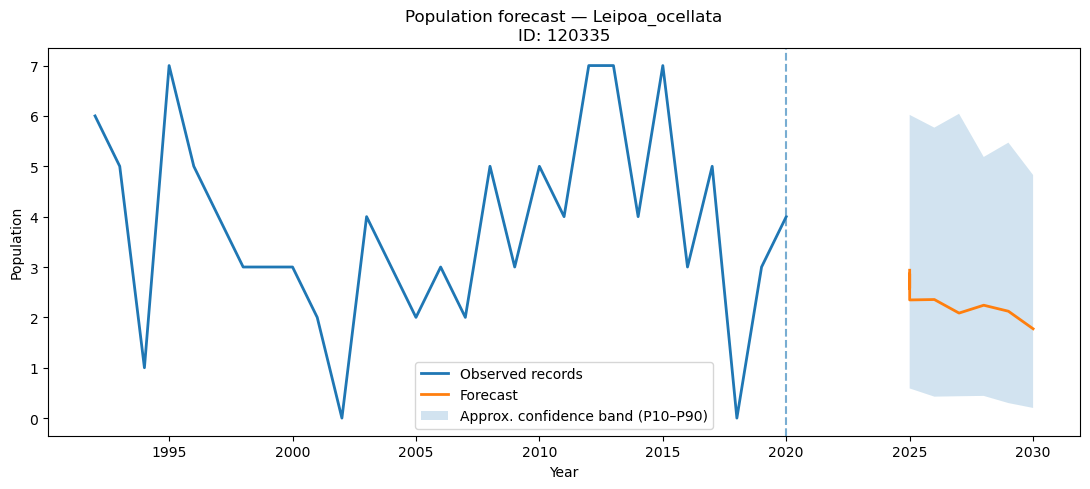

Summary:


,population_id,horizon_years,best_forecast_experiment,best_forecast_model,local_driver_model
0,120335,10,forecast_plus_land_use,RandomForest,HistGBR


Metadata:


,field,value
0,series_id,120335
1,id,120335
2,binomial,Leipoa_ocellata
3,common_name,Malleefowl
4,class,Aves
5,family,Megapodiidae
6,country,australia
7,country_norm,australia
8,location,Lowan Mallee
9,units,proxy: breeding pairs


Top 3 drivers:


,feature,importance_mean,importance_std,model,directional_q90_minus_q10_effect
0,temp_avg_c_anomaly_country,0.0,0.0,HistGBR,0.0
1,precip_mm_anomaly_country,0.0,0.0,HistGBR,0.0
2,forest_share_pct_change,0.0,0.0,HistGBR,0.0


IUCN lookup:


,binomial,current_iucn_category,current_assessment_year,future_target_year,future_iucn_category,note
0,Leipoa_ocellata,None,None,2030,None,No future IUCN category available in the local...


In [28]:
# =========================================================
# 11F. EXAMPLE APPLICATION CALL
# =========================================================
# Replace EXAMPLE_SERIES_ID with any valid population_id / series_id from your data.
application_output = analyze_population(
    population_id=EXAMPLE_SERIES_ID,
    horizon_years=10,
    future_env_strategy="hold_last",
    show_plot=True,
)

print("Summary:")
display(pd.DataFrame([application_output["summary"]]))

print("Metadata:")
display(application_output["metadata"])

print("Top 3 drivers:")
display(application_output["top3_drivers"])

print("IUCN lookup:")
display(pd.DataFrame([application_output["iucn"]]) if application_output["iucn"] is not None else pd.DataFrame())

## 12. How to use the notebook cleanly

### For the global story
Use:
- `results_df`
- the performance plots
- the global permutation-importance plots

### For the local story
Use:
- `top3_local_drivers`
- the `analyze_population(...)` output

### For the app / API story
The cleanest function is:

```python
analyze_population(
    population_id="...",
    horizon_years=10,
)
```

### What the function can and cannot claim
It can provide:
- a recursive forecast with uncertainty bands,
- the top environmental drivers inside the model,
- the current global IUCN category **if you provide a lookup table**,
- a future IUCN category **only if you provide a scenario lookup table**.

It cannot honestly infer a future IUCN category from the current one without a dedicated external projection source.